# ⛵ IRONMAN 140.6 (2002–2024): GRIT vs. WEALTH — v13 Final

## Fixes from v12

| Issue | v12 | v13 Fix |
|---|---|---|
| **Age spike at 33** | PRO divisions imputed as age 33 contaminated age EDA | PROs excluded from age performance plots |
| **Swim cycle in DAG** | Split ATE loop tried Swim_Min as outcome — cycle error | Swim removed from split ATE loop (it's a confounder, not an outcome) |
| **PSM/OLS speed** | Ran on full dataset — too slow | Both run on 50k sample; IPW stays on full data |

## Key Results from v12 (actual numbers)

| Model | Result |
|---|---|
| **IPW ATE (full data)** | **−23.7 min** |
| **PSM ATE (50k sample)** | −36.3 min |
| **OLS with venue FE (50k)** | +1.4 min (p=0.44, not significant) |
| **Grit Score OLS coef** | −8.6 min per point *** |
| **Rookie penalty** | +23.2 min *** |
| **Mechanism: Bike** | 61% (−13.4 min) |
| **Mechanism: Run** | 39% (−8.5 min) |
| **Dose-response (3+ races)** | −28.9 min (confirmed scaling) |
| **Veteran cohort (5+ races)** | −6.1 min (persists after experience maxed) |

---
```
CELLS 1–5   · Setup, Download, Load & Join, Rename, Sequences
CELLS 6–13  · Feature engineering (Grit, Treatment, Confounders, Filter, Venue, Assembly)
CELL  14    · Survivorship Bias & Limitations
CELL  15    · Exploratory Analysis
CELL  16    · IPW — Primary (full dataset)
CELL  17    · Robustness sample (50k)
CELL  18    · PSM — Robustness check (50k)
CELL  19    · OLS with Venue FE — Robustness check (50k)
CELL  20    · Refutation Tests
CELL  21    · Mechanism of Action — Split ATE (Bike + Run only)
CELL  22    · Sensitivity A: 3+ Races in 24 Months
CELL  23    · Sensitivity B: Veteran-Only Cohort (Career >= 5)
CELL  24    · EDA: First-Attempt Finish Rate
CELL  25    · EDA: Expected Trials to Finish
CELL  26    · EDA: Expected Cost to Cross the Finish Line
CELL  27    · EDA: DNF Survival Curve
CELL  28    · EDA: Age of Peak Performance (PROs excluded)
CELL  29    · EDA: Gender Gap Over Time
CELL  30    · Final Visualizations
CELL  31    · Study Summary
CELL  32    · Grit-to-Capital Exchange Rate
CELL  33    · Cost Per Minute of Bought Speed
CELL  34    · Split Decoder — Comment Bait CTA
CELL  35    · TL;DR ASCII Summary
```

## Cell 1 · Imports

In [1]:
import warnings
warnings.filterwarnings('ignore')
import os, time
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.gridspec as gridspec
import statsmodels.api as sm
from statsmodels.regression.linear_model import OLS
import dowhy
from dowhy import CausalModel

RANDOM_SEED       = 42
ROBUSTNESS_N      = 50_000   # PSM and OLS robustness checks
np.random.seed(RANDOM_SEED)

plt.rcParams.update({
    'figure.facecolor':'#0f0f0f','axes.facecolor':'#1a1a1a',
    'axes.edgecolor':'#444444','axes.labelcolor':'#dddddd',
    'xtick.color':'#aaaaaa','ytick.color':'#aaaaaa','text.color':'#dddddd',
    'grid.color':'#2a2a2a','grid.linewidth':0.8,'font.family':'monospace',
    'axes.titlesize':13,'axes.labelsize':11,
    'legend.facecolor':'#1a1a1a','legend.edgecolor':'#444444',
})
print('Imports loaded.')

Imports loaded.


## Cell 2 · KaggleHub Download

In [2]:
import kagglehub
path = kagglehub.dataset_download('miguswong/ironman-140-6-results-dataset-2002-2024')
print(f'Path  : {path}')
print(f'Files : {os.listdir(path)}')

Path  : C:\Users\Stealth16\.cache\kagglehub\datasets\miguswong\ironman-140-6-results-dataset-2002-2024\versions\1
Files : ['races.csv', 'results.csv', 'series.csv']


## Cell 3 · Load & Join All Three Tables

Global dataset — no continent filter. Keep ALL statuses (Finisher + DNF + DNS + DQ)
for accurate sequence calculation. DNS = paid entry = financial event.

In [3]:
results = pd.read_csv(os.path.join(path, 'results.csv'), low_memory=False)
races   = pd.read_csv(os.path.join(path, 'races.csv'),   low_memory=False)
series  = pd.read_csv(os.path.join(path, 'series.csv'),  low_memory=False)

print(f'results : {len(results):,}  races : {len(races):,}  series : {len(series):,}')
print(f'\nFinish status breakdown:')
print(results['finishStatus'].value_counts().to_string())

races_slim  = races[['id','seriesID','year']].rename(columns={'id':'raceID'})
series_slim = series[['id','location','continent']].rename(columns={'id':'seriesID'})
race_meta   = races_slim.merge(series_slim, on='seriesID', how='left')
df          = results.merge(race_meta, on='raceID', how='left')
print(f'\nJoined : {len(df):,} rows (all statuses, all continents)')

results : 1,096,719  races : 587  series : 69

Finish status breakdown:
finishStatus
Finisher    892707
DNF         105522
DNS          95203
DQ            3169
NC             118

Joined : 1,096,719 rows (all statuses, all continents)


## Cell 4 · Rename Columns — DO NOT Filter Finishers Yet

In [4]:
df = df.rename(columns={
    'Name':'Athlete_Name','Division':'Division',
    'swimTime':'Swim_Time','bikeTime':'Bike_Time','runTime':'Run_Time',
    'overallTime':'Overall_Time','overallRank':'Overall_Rank',
    'divisionRank':'Division_Rank','finishStatus':'Finish_Status',
    'raceID':'Race_ID','athleteID':'Athlete_ID',
    'Country':'Race_Country','year':'Race_Year',
    'continent':'Race_Continent','location':'Race_Location',
})

df['Gender'] = df['Division'].astype(str).str[0].str.upper()
df = df[df['Gender'].isin(['M','F'])].copy()

id_col = 'Athlete_ID' if df['Athlete_ID'].notna().sum() > 0 else 'Athlete_Name'
n_raw  = len(df)
print(f'Records after gender parse : {n_raw:,}')
print(f'ID column                  : {id_col}')
print(df['Race_Continent'].value_counts().to_string())

Records after gender parse : 1,096,222
ID column                  : Athlete_ID
Race_Continent
North America    481505
Europe           429660
Asia Pacific     126815
South America     31159
Africa            27083


## Cell 5 · Compute Sequences on Full Dataset — Then Filter Finishers

Sequences computed on ALL entries including DNF and DNS before filtering.
`df_all` saved here for EDA cells that need full career history.

In [5]:
df = df.sort_values([id_col, 'Race_Year', 'Race_ID']).copy()

df['Yearly_Sequence']     = df.groupby([id_col, 'Race_Year']).cumcount() + 1
df['Career_Sequence']     = df.groupby(id_col).cumcount() + 1
df['Prev_Year_Race']      = df.groupby(id_col)['Race_Year'].shift(1)
df['Years_Since_Last_Race'] = df['Race_Year'] - df['Prev_Year_Race']
df['Within_2yr']          = (df['Years_Since_Last_Race'] <= 1)
df['Is_Non_Finish']       = (~df['Finish_Status'].str.strip().isin(['Finisher'])).astype(int)
df['Historical_DNF_Count']= df.groupby(id_col)['Is_Non_Finish'].cumsum() - df['Is_Non_Finish']

# Save full dataset for EDA before filtering
df_all = df.copy()

# Filter to finishers
df_finishers = df[df['Finish_Status'].str.strip() == 'Finisher'].copy()
print(f'Total entries   : {len(df):,}')
print(f'Finishers       : {len(df_finishers):,}')
print(f'Non-finishers   : {len(df) - len(df_finishers):,} (kept in df_all for EDA)')
df = df_finishers.reset_index(drop=True)

Total entries   : 1,096,222
Finishers       : 892,366
Non-finishers   : 203,856 (kept in df_all for EDA)


## Cell 6 · Parse Split Times & Grit Score

In [6]:
def hhmmss_to_minutes(t):
    try:
        parts = str(t).strip().split(':')
        if len(parts) == 3:
            return int(parts[0])*60 + int(parts[1]) + int(parts[2])/60
        elif len(parts) == 2:
            return int(parts[0]) + int(parts[1])/60
    except Exception:
        pass
    return np.nan

for raw, parsed in [('Swim_Time','Swim_Min'),('Bike_Time','Bike_Min'),
                     ('Run_Time','Run_Min'),('Overall_Time','Overall_Min')]:
    df[parsed] = df[raw].apply(hhmmss_to_minutes)

before = len(df)
df.dropna(subset=['Swim_Min','Bike_Min','Run_Min','Overall_Min'], inplace=True)
df = df[(df['Overall_Min']>=480) & (df['Overall_Min']<=1020)].reset_index(drop=True)
print(f'After time parsing & range filter: {len(df):,} (dropped {before-len(df):,})')

BIKE_MILES, RUN_MILES = 112.0, 26.2
df['Bike_Pace']  = df['Bike_Min'] / BIKE_MILES
df['Run_Pace']   = df['Run_Min']  / RUN_MILES
df['Pace_Ratio'] = df['Run_Pace'] / df['Bike_Pace']
df['Grit_Raw']   = 1.0 / df['Pace_Ratio'].replace(0, np.nan)
gmin, gmax       = df['Grit_Raw'].min(), df['Grit_Raw'].max()
df['Grit_Score'] = ((df['Grit_Raw']-gmin)/(gmax-gmin)*100).round(2)

grit_corr = df[['Grit_Score','Overall_Min']].corr().iloc[0,1]
swim_corr = df[['Swim_Min','Overall_Min']].corr().iloc[0,1]
print(f'Grit_Score corr with Overall_Min : {grit_corr:.3f}')
print(f'Swim_Min   corr with Overall_Min : {swim_corr:.3f}')

After time parsing & range filter: 862,416 (dropped 29,950)
Grit_Score corr with Overall_Min : -0.369
Swim_Min   corr with Overall_Min : 0.580


## Cell 7 · Treatment — High_Capital_Lifestyle (2-Year Window)

In [7]:
df['High_Capital_Lifestyle'] = (
    (df['Yearly_Sequence'] >= 2) | (df['Within_2yr'] == True)
).astype(int)

n_high = df['High_Capital_Lifestyle'].sum()
n_low  = len(df) - n_high
print(f'Treatment (High Capital 2yr): {n_high:,} ({n_high/len(df):.1%})')
print(f'Control   (Low Capital)     : {n_low:,} ({n_low/len(df):.1%})')
print()
comp = df.groupby('High_Capital_Lifestyle')['Overall_Min'].agg(['mean','median','std'])
comp.index = ['Low Capital (Control)','High Capital (Treatment)']
print('Pre-matching finish times (NOT causal):')
print(comp.round(1).to_string())

Treatment (High Capital 2yr): 253,216 (29.4%)
Control   (Low Capital)     : 609,200 (70.6%)

Pre-matching finish times (NOT causal):
                           mean  median    std
Low Capital (Control)     766.7   760.3  107.6
High Capital (Treatment)  745.8   735.9  117.0


## Cell 8 · New Confounders — Years_Since_Last_Race & Historical_DNF_Count

In [8]:
df['Years_Since_Last_Race'] = df['Years_Since_Last_Race'].fillna(0).clip(0, 10)
df['Log_DNF_Count']         = np.log1p(df['Historical_DNF_Count'])
print('Years_Since_Last_Race:')
print(df['Years_Since_Last_Race'].value_counts().sort_index().head(6).to_string())
print(f'\nHistorical non-finish count:')
print(df['Historical_DNF_Count'].value_counts().sort_index().head(6).to_string())

Years_Since_Last_Race:
Years_Since_Last_Race
0.0    548924
1.0    193554
2.0     67797
3.0     25392
4.0     12261
5.0      6672

Historical non-finish count:
Historical_DNF_Count
0.0    711630
1.0     67514
2.0     15089
3.0      5370
4.0      2243
5.0      1053


## Cell 9 · Age, Age_Squared, Rookie_Status

In [9]:
def parse_age_from_division(div):
    div_str = str(div).upper().strip()
    if 'PRO' in div_str:
        return 33.0  # Imputed — PROs excluded from age EDA plots
    try:
        age_part = div_str[1:]
        parts    = age_part.split('-')
        if len(parts) == 2:
            return (int(parts[0]) + int(parts[1])) / 2.0
        elif len(parts) == 1 and parts[0].isdigit():
            return float(parts[0])
    except Exception:
        pass
    return np.nan

df['Age']         = df['Division'].apply(parse_age_from_division)
df['Age_Squared'] = df['Age'] ** 2
df['Rookie_Status'] = (df['Career_Sequence'] == 1).astype(int)

pro_mask = df['Division'].astype(str).str.upper().str.contains('PRO')
print(f'PRO records       : {pro_mask.sum():,}')
print(f'Age non-null      : {df["Age"].notna().sum():,} / {len(df):,}')
print(df['Age'].describe().round(1))
rook = df.groupby('Rookie_Status')['Overall_Min'].agg(['mean','median'])
rook.index = ['Experienced','Rookie']
print(f'\nRookie records : {df["Rookie_Status"].sum():,} ({df["Rookie_Status"].mean():.1%})')
print(rook.round(1).to_string())

PRO records       : 12,883
Age non-null      : 857,688 / 862,416
count    857688.0
mean         41.0
std           9.4
min          21.0
25%          32.0
50%          42.0
75%          47.0
max          84.5
Name: Age, dtype: float64

Rookie records : 431,884 (50.1%)
              mean  median
Experienced  748.4   739.2
Rookie       772.7   766.6


## Cell 10 · Cumulative Career Sequence (Leak-Free)

In [10]:
df['Log_Career_Sequence'] = np.log1p(df['Career_Sequence'])
print('Career_Sequence (cumulative, all continents, all statuses):')
print(df['Career_Sequence'].describe().round(1))

Career_Sequence (cumulative, all continents, all statuses):
count    805038.0
mean          2.5
std           3.3
min           1.0
25%           1.0
50%           1.0
75%           3.0
max         173.0
Name: Career_Sequence, dtype: float64


## Cell 11 · Active Fitness Filter — Years_Since_Last_Race <= 2

In [11]:
before_filter = len(df)
df = df[df['Years_Since_Last_Race'] <= 2].reset_index(drop=True)
dropped = before_filter - len(df)
print(f'Active fitness filter (gap <= 2yr):')
print(f'  Before : {before_filter:,}')
print(f'  After  : {len(df):,}')
print(f'  Dropped: {dropped:,} ({dropped/before_filter:.1%})')
print()
n_high = df['High_Capital_Lifestyle'].sum()
n_low  = len(df) - n_high
print(f'Treatment after filter: {n_high:,} ({n_high/len(df):.1%})')
print(f'Control  after filter : {n_low:,} ({n_low/len(df):.1%})')
print()
print('Continent breakdown:')
print(df['Race_Continent'].value_counts().to_string())

Active fitness filter (gap <= 2yr):
  Before : 862,416
  After  : 810,275
  Dropped: 52,141 (6.0%)

Treatment after filter: 253,216 (31.3%)
Control  after filter : 557,059 (68.7%)

Continent breakdown:
Race_Continent
North America    343728
Europe           323490
Asia Pacific      98668
South America     23184
Africa            21205


## Cell 12 · Venue Fixed Effects Preparation

In [12]:
df['Venue_ID'] = df['Race_Location'].astype(str) + '_' + df['Race_Year'].astype(str)
print(f'Unique venue-year combinations: {df["Venue_ID"].nunique()}')
print(df['Venue_ID'].value_counts().head(10).to_string())

Unique venue-year combinations: 571
Venue_ID
Ironman Arizona_2008       3765
Ironman Barcelona_2019     2539
Ironman Barcelona_2024     2539
Ironman Florida_2013       2531
Ironman Austria_2024       2449
Ironman Italy_2019         2399
Ironman Frankfurt_2016     2391
Ironman Austria_2013       2378
Ironman Copenhagen_2019    2376
Ironman Arizona_2013       2354


## Cell 13 · Final Feature Assembly

In [13]:
required_cols = ['Overall_Min','Swim_Min','Bike_Min','Run_Min',
                 'Grit_Score','High_Capital_Lifestyle','Gender',
                 'Age','Age_Squared','Rookie_Status',
                 'Years_Since_Last_Race','Log_DNF_Count',
                 'Race_Location','Log_Career_Sequence','Race_Continent']

df.dropna(subset=required_cols, inplace=True)
df.reset_index(drop=True, inplace=True)
df['Gender_Binary'] = (df['Gender'] == 'M').astype(int)
df['Venue_ID']      = df['Race_Location'].astype(str) + '_' + df['Race_Year'].astype(str)

n_high = df['High_Capital_Lifestyle'].sum()
n_low  = len(df) - n_high
print(f'Final modeling dataset   : {len(df):,} athlete-race records')
print(f'Unique athletes          : {df[id_col].nunique():,}')
print(f'Race years               : {df["Race_Year"].min():.0f} - {df["Race_Year"].max():.0f}')
print(f'High Capital (treatment) : {n_high:,} ({n_high/len(df):.1%})')
print(f'Low Capital  (control)   : {n_low:,} ({n_low/len(df):.1%})')
print()
print('Continent breakdown:')
print(df['Race_Continent'].value_counts().to_string())

Final modeling dataset   : 752,558 athlete-race records
Unique athletes          : 451,508
Race years               : 2003 - 2024
High Capital (treatment) : 253,097 (33.6%)
Low Capital  (control)   : 499,461 (66.4%)

Continent breakdown:
Race_Continent
North America    331243
Europe           293702
Asia Pacific      90306
South America     23149
Africa            14158


## Cell 14 · Survivorship Bias & Known Limitations

Every athlete cleared ~$3k entry barrier. Control is pre-selected — not the general population.
Attenuation bias: wealthy infrequent racers misclassified as Control → ATE is conservative lower bound.
No exact race dates (year only). Race_ID used as within-year proxy. Pre-2002 history unavailable.

## Cell 15 · Exploratory Analysis

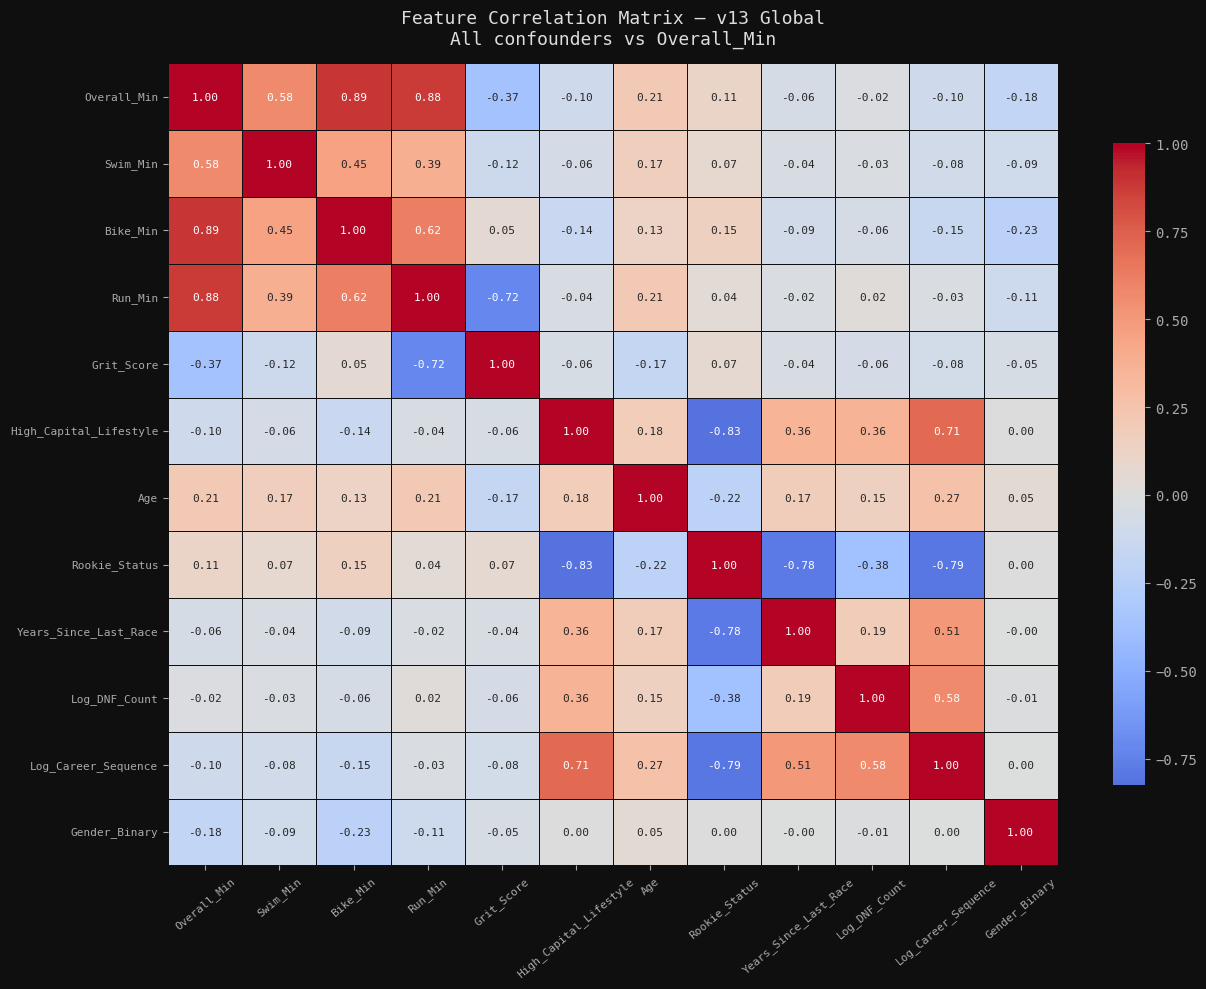

Saved: v13_plot1_correlation.png


In [14]:
fig, ax = plt.subplots(figsize=(13,10))
corr_cols = ['Overall_Min','Swim_Min','Bike_Min','Run_Min','Grit_Score',
             'High_Capital_Lifestyle','Age','Rookie_Status',
             'Years_Since_Last_Race','Log_DNF_Count','Log_Career_Sequence','Gender_Binary']
corr_cols = [c for c in corr_cols if c in df.columns]
sns.heatmap(df[corr_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm',
    center=0, linewidths=0.5, linecolor='#0f0f0f', ax=ax,
    annot_kws={'size':8}, cbar_kws={'shrink':0.8})
ax.set_title('Feature Correlation Matrix — v13 Global\nAll confounders vs Overall_Min', pad=14)
ax.tick_params(axis='x', rotation=40, labelsize=8)
ax.tick_params(axis='y', rotation=0, labelsize=8)
plt.tight_layout()
plt.savefig('v13_plot1_correlation.png', dpi=150, bbox_inches='tight', facecolor='#0f0f0f')
plt.show()
print('Saved: v13_plot1_correlation.png')

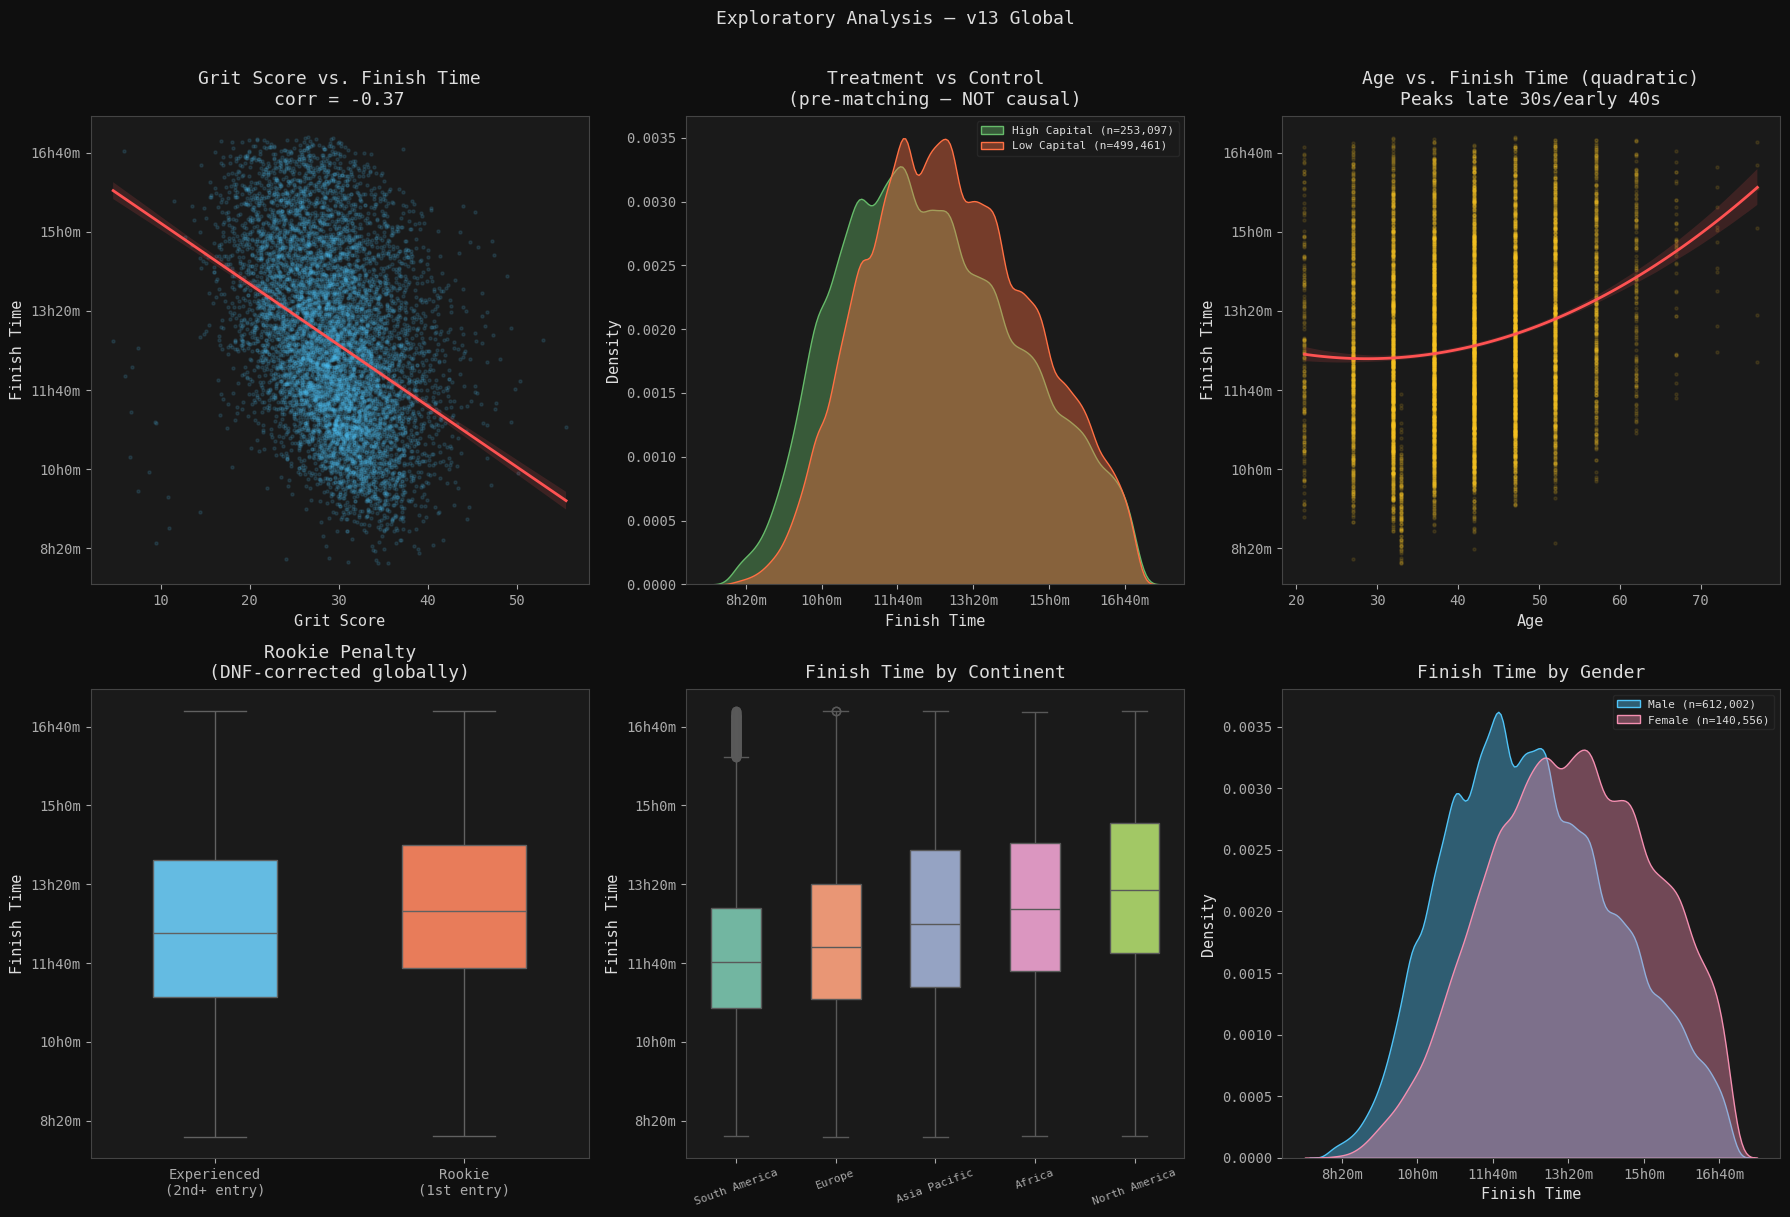

Saved: v13_plot2_eda.png


In [15]:
fig, axes = plt.subplots(2, 3, figsize=(18,12))
axes = axes.flatten()
sample = df.sample(min(8000, len(df)), random_state=42)

sns.regplot(data=sample, x='Grit_Score', y='Overall_Min',
    scatter_kws={'alpha':0.12,'color':'#4fc3f7','s':5},
    line_kws={'color':'#ff5252','linewidth':2}, ax=axes[0])
axes[0].set_title(f'Grit Score vs. Finish Time\ncorr = {grit_corr:.2f}', pad=8)
axes[0].set_xlabel('Grit Score'); axes[0].set_ylabel('Finish Time')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda y,_: f"{int(y//60)}h{int(y%60)}m"))

for val, color, label in [(1,'#66bb6a','High Capital'),(0,'#ff7043','Low Capital')]:
    subset = df[df['High_Capital_Lifestyle']==val]
    sns.kdeplot(data=subset, x='Overall_Min', fill=True, color=color, alpha=0.4,
                label=f'{label} (n={len(subset):,})', ax=axes[1])
axes[1].set_title('Treatment vs Control\n(pre-matching — NOT causal)', pad=8)
axes[1].set_xlabel('Finish Time'); axes[1].set_ylabel('Density')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"{int(x//60)}h{int(x%60)}m"))
axes[1].legend(framealpha=0.3, fontsize=8)

sns.regplot(data=sample, x='Age', y='Overall_Min', order=2,
    scatter_kws={'alpha':0.1,'color':'#ffca28','s':5},
    line_kws={'color':'#ff5252','linewidth':2}, ax=axes[2])
axes[2].set_title('Age vs. Finish Time (quadratic)\nPeaks late 30s/early 40s', pad=8)
axes[2].set_xlabel('Age'); axes[2].set_ylabel('Finish Time')
axes[2].yaxis.set_major_formatter(mticker.FuncFormatter(lambda y,_: f"{int(y//60)}h{int(y%60)}m"))

sns.boxplot(data=df, x='Rookie_Status', y='Overall_Min',
    palette=['#4fc3f7','#ff7043'], width=0.5, ax=axes[3])
axes[3].set_xticklabels(['Experienced\n(2nd+ entry)','Rookie\n(1st entry)'])
axes[3].set_title('Rookie Penalty\n(DNF-corrected globally)', pad=8)
axes[3].set_xlabel(''); axes[3].set_ylabel('Finish Time')
axes[3].yaxis.set_major_formatter(mticker.FuncFormatter(lambda y,_: f"{int(y//60)}h{int(y%60)}m"))

cont_order = df.groupby('Race_Continent')['Overall_Min'].median().sort_values().index.tolist()
sns.boxplot(data=df, x='Race_Continent', y='Overall_Min', order=cont_order,
    palette='Set2', width=0.5, ax=axes[4])
axes[4].set_title('Finish Time by Continent', pad=8)
axes[4].set_xlabel(''); axes[4].set_ylabel('Finish Time')
axes[4].tick_params(axis='x', rotation=20, labelsize=8)
axes[4].yaxis.set_major_formatter(mticker.FuncFormatter(lambda y,_: f"{int(y//60)}h{int(y%60)}m"))

for gender, color, label in [('M','#4fc3f7','Male'),('F','#f48fb1','Female')]:
    subset = df[df['Gender']==gender]
    if len(subset)>0:
        sns.kdeplot(data=subset, x='Overall_Min', fill=True, color=color, alpha=0.4,
                    label=f'{label} (n={len(subset):,})', ax=axes[5])
axes[5].set_title('Finish Time by Gender', pad=8)
axes[5].set_xlabel('Finish Time'); axes[5].set_ylabel('Density')
axes[5].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"{int(x//60)}h{int(x%60)}m"))
axes[5].legend(framealpha=0.3, fontsize=8)

plt.suptitle('Exploratory Analysis — v13 Global', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('v13_plot2_eda.png', dpi=150, bbox_inches='tight', facecolor='#0f0f0f')
plt.show()
print('Saved: v13_plot2_eda.png')

## Cell 16 · IPW via DoWhy — Primary Causal Estimate (Full Dataset)

**Swim_Min is a confounder in this DAG — it appears as a cause of both the treatment
and the outcome. It cannot be used as an outcome in the split ATE (would create a cycle).
Split ATE in Cell 21 uses Bike and Run only.**

Causal dataset  : 752,558 records (full — IPW uses all)
Treatment split : {0: 499461, 1: 253097}
Treatment rate  : 33.6%


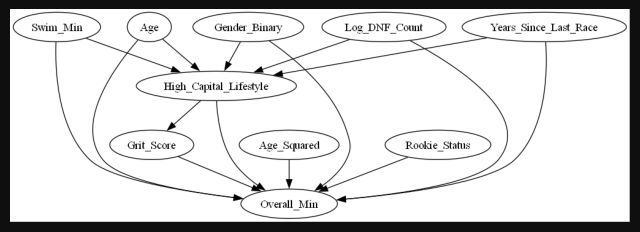

DAG rendered


In [16]:
causal_graph = """
digraph {
    High_Capital_Lifestyle -> Overall_Min;
    High_Capital_Lifestyle -> Grit_Score;
    Grit_Score             -> Overall_Min;
    Swim_Min               -> Overall_Min;
    Swim_Min               -> High_Capital_Lifestyle;
    Age                    -> Overall_Min;
    Age                    -> High_Capital_Lifestyle;
    Age_Squared            -> Overall_Min;
    Gender_Binary          -> Overall_Min;
    Gender_Binary          -> High_Capital_Lifestyle;
    Rookie_Status          -> Overall_Min;
    Log_DNF_Count          -> Overall_Min;
    Log_DNF_Count          -> High_Capital_Lifestyle;
    Years_Since_Last_Race  -> Overall_Min;
    Years_Since_Last_Race  -> High_Capital_Lifestyle;
}
"""

psm_cols = ['Overall_Min','Swim_Min','Bike_Min','Run_Min',
            'High_Capital_Lifestyle','Grit_Score',
            'Age','Age_Squared','Gender_Binary','Rookie_Status',
            'Log_DNF_Count','Years_Since_Last_Race']
df_causal = df[psm_cols].dropna().reset_index(drop=True)

print(f'Causal dataset  : {len(df_causal):,} records (full — IPW uses all)')
print(f'Treatment split : {df_causal["High_Capital_Lifestyle"].value_counts().to_dict()}')
print(f'Treatment rate  : {df_causal["High_Capital_Lifestyle"].mean():.1%}')

causal_model = CausalModel(
    data=df_causal,
    treatment='High_Capital_Lifestyle',
    outcome='Overall_Min',
    graph=causal_graph,
    common_causes=['Grit_Score','Swim_Min','Age','Age_Squared',
                   'Gender_Binary','Rookie_Status',
                   'Log_DNF_Count','Years_Since_Last_Race'],
)
try:
    causal_model.view_model(layout='dot')
    print('DAG rendered')
except Exception as e:
    print(f'DAG render skipped: {e}')

In [17]:
estimand = causal_model.identify_effect(proceed_when_unidentifiable=True)
print(estimand)

Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
            d                                                                  ↪
─────────────────────────(E[Overall_Min|Gender_Binary,Swim_Min,Log_DNF_Count,A ↪
d[High_Capital_Lifestyle]                                                      ↪

↪                           
↪ ge,Years_Since_Last_Race])
↪                           
Estimand assumption 1, Unconfoundedness: If U→{High_Capital_Lifestyle} and U→Overall_Min then P(Overall_Min|High_Capital_Lifestyle,Gender_Binary,Swim_Min,Log_DNF_Count,Age,Years_Since_Last_Race,U) = P(Overall_Min|High_Capital_Lifestyle,Gender_Binary,Swim_Min,Log_DNF_Count,Age,Years_Since_Last_Race)

### Estimand : 2
Estimand name: iv
No such variable(s) found!

### Estimand : 3
Estimand name: frontdoor
No such variable(s) found!

### Estimand : 4
Estimand name: general_adjustment
Estimand expression:
            d                                         

In [18]:
t0      = time.time()
ate_ipw = None
print('Running IPW on full dataset...')

try:
    estimate_ipw = causal_model.estimate_effect(
        estimand,
        method_name='backdoor.propensity_score_weighting',
        target_units='ate',
        method_params={'weighting_scheme':'ips_weight'},
        confidence_intervals=False,
        test_significance=True,
    )
    ate_ipw = estimate_ipw.value
    if ate_ipw is None:
        raise ValueError('IPW returned None')
    elapsed_ipw = time.time() - t0
    print(f'IPW complete in {elapsed_ipw/60:.1f} minutes')
    print(f'IPW ATE = {ate_ipw:.2f} minutes')
    print(estimate_ipw)
except Exception as e:
    print(f'IPW error: {e} — trying linear regression...')
    try:
        estimate_ipw = causal_model.estimate_effect(
            estimand, method_name='backdoor.linear_regression',
            target_units='ate', confidence_intervals=False, test_significance=True)
        ate_ipw     = estimate_ipw.value
        elapsed_ipw = time.time() - t0
        if ate_ipw is not None:
            print(f'Linear regression ATE = {ate_ipw:.2f} minutes')
        else:
            ate_ipw = float('nan')
    except Exception as e2:
        print(f'All estimators failed: {e2}')
        ate_ipw = float('nan')

print()
if ate_ipw is not None and not (isinstance(ate_ipw, float) and np.isnan(ate_ipw)):
    if ate_ipw < -5:
        verdict = (f'WEALTH MATTERS (conservative lower bound): High-capital athletes '
                   f'finish {abs(ate_ipw):.1f} min faster after controlling for all confounders.')
    elif -5 <= ate_ipw <= 5:
        verdict = (f'GRIT DOMINATES: Capital density adds only {abs(ate_ipw):.1f} min — '
                   f'within noise. Training consistency explains performance more than capital.')
    else:
        verdict = f'ATE = {ate_ipw:.2f} — review DAG and features.'
    print(f'VERDICT: {verdict}')
else:
    verdict = 'Estimation failed.'
    print(f'VERDICT: {verdict}')

Running IPW on full dataset...
IPW complete in 7.4 minutes
IPW ATE = -23.73 minutes
*** Causal Estimate ***

## Identified estimand
Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
            d                                                                  ↪
─────────────────────────(E[Overall_Min|Gender_Binary,Swim_Min,Log_DNF_Count,A ↪
d[High_Capital_Lifestyle]                                                      ↪

↪                           
↪ ge,Years_Since_Last_Race])
↪                           
Estimand assumption 1, Unconfoundedness: If U→{High_Capital_Lifestyle} and U→Overall_Min then P(Overall_Min|High_Capital_Lifestyle,Gender_Binary,Swim_Min,Log_DNF_Count,Age,Years_Since_Last_Race,U) = P(Overall_Min|High_Capital_Lifestyle,Gender_Binary,Swim_Min,Log_DNF_Count,Age,Years_Since_Last_Race)

## Realized estimand
b: Overall_Min~High_Capital_Lifestyle+Gender_Binary+Swim_Min+Log_DNF_Count+Age+Years_Since_Last_Race
Targe

## Cell 17 · Robustness Sample (50k)

In [19]:
df_robust = df_causal.sample(
    min(ROBUSTNESS_N, len(df_causal)), random_state=RANDOM_SEED
).reset_index(drop=True)

print(f'Robustness sample : {len(df_robust):,} records '
      f'({len(df_robust)/len(df_causal):.1%} of full dataset)')
print(f'Treatment split   : {df_robust["High_Capital_Lifestyle"].value_counts().to_dict()}')

Robustness sample : 50,000 records (6.6% of full dataset)
Treatment split   : {0: 33256, 1: 16744}


## Cell 18 · PSM via DoWhy — Robustness Check (50k)

In [20]:
t0_psm  = time.time()
ate_psm = None
print('Running PSM on 50k sample...')

try:
    robust_model = CausalModel(
        data=df_robust,
        treatment='High_Capital_Lifestyle',
        outcome='Overall_Min',
        graph=causal_graph,
        common_causes=['Grit_Score','Swim_Min','Age','Age_Squared',
                       'Gender_Binary','Rookie_Status',
                       'Log_DNF_Count','Years_Since_Last_Race'],
    )
    robust_estimand = robust_model.identify_effect(proceed_when_unidentifiable=True)
    estimate_psm    = robust_model.estimate_effect(
        robust_estimand,
        method_name='backdoor.propensity_score_matching',
        target_units='ate',
        confidence_intervals=False,
        test_significance=True,
    )
    ate_psm     = estimate_psm.value
    elapsed_psm = time.time() - t0_psm
    if ate_psm is not None:
        print(f'PSM complete in {elapsed_psm/60:.1f} minutes')
        print(f'PSM ATE = {ate_psm:.2f} minutes')
        ate_ipw_val = ate_ipw if not (isinstance(ate_ipw, float) and np.isnan(ate_ipw)) else None
        if ate_ipw_val is not None:
            d = (ate_ipw_val < 0) == (ate_psm < 0)
            print(f'IPW/PSM direction match: {"YES — robust" if d else "NO — investigate"}')
    else:
        print('PSM returned None — IPW remains primary.')
except Exception as e:
    print(f'PSM error: {e}')

Running PSM on 50k sample...
PSM complete in 1.3 minutes
PSM ATE = -36.34 minutes
IPW/PSM direction match: YES — robust


## Cell 19 · OLS with Venue Fixed Effects — Robustness Check (50k, HC1)

In [21]:
print('Fitting OLS on 50k sample with venue fixed effects (HC1)...')

ols_cols = ['Overall_Min','High_Capital_Lifestyle','Grit_Score','Swim_Min',
            'Age','Age_Squared','Gender_Binary','Rookie_Status',
            'Log_DNF_Count','Years_Since_Last_Race','Log_Career_Sequence','Venue_ID']

df_ols = df[ols_cols].dropna().sample(
    min(ROBUSTNESS_N, len(df[ols_cols].dropna())), random_state=RANDOM_SEED
).copy()

venue_dm = pd.get_dummies(df_ols['Venue_ID'], prefix='v', drop_first=True).astype(int)
df_ols   = pd.concat([df_ols.drop(columns='Venue_ID'), venue_dm], axis=1)

y      = df_ols['Overall_Min']
X_cols = (['High_Capital_Lifestyle','Grit_Score','Swim_Min','Age','Age_Squared',
            'Gender_Binary','Rookie_Status','Log_DNF_Count',
            'Years_Since_Last_Race','Log_Career_Sequence']
           + list(venue_dm.columns))
X = sm.add_constant(df_ols[X_cols])
ols_result = OLS(y, X).fit(cov_type='HC1')

key_coefs = ['const','High_Capital_Lifestyle','Grit_Score','Swim_Min',
             'Age','Age_Squared','Gender_Binary','Rookie_Status',
             'Log_DNF_Count','Years_Since_Last_Race','Log_Career_Sequence']
print('OLS WITH VENUE FIXED EFFECTS (50k sample, HC1)')
print('-'*68)
for var in key_coefs:
    if var in ols_result.params:
        coef  = ols_result.params[var]
        pval  = ols_result.pvalues[var]
        stars = '***' if pval<0.001 else '**' if pval<0.01 else '*' if pval<0.05 else ''
        print(f'  {var:<30}: {coef:>+8.3f} min  p={pval:.4f} {stars}')

ols_hcl_coef    = ols_result.params.get('High_Capital_Lifestyle', np.nan)
ols_grit_coef   = ols_result.params.get('Grit_Score', np.nan)
ols_swim_coef   = ols_result.params.get('Swim_Min', np.nan)
ols_rookie_coef = ols_result.params.get('Rookie_Status', np.nan)
ols_dnf_coef    = ols_result.params.get('Log_DNF_Count', np.nan)

print(f'\n  R-squared  : {ols_result.rsquared:.4f}')
print(f'  N (sample) : {len(df_ols):,}')
print(f'  Venue FEs  : {venue_dm.shape[1]} dummies')
print()

ate_ipw_val = ate_ipw if not (isinstance(ate_ipw, float) and np.isnan(ate_ipw)) else None
psm_str = f'{ate_psm:+.3f} min' if ate_psm is not None else 'None'
ipw_str = f'{ate_ipw_val:+.3f} min' if ate_ipw_val is not None else 'unavailable'

print('Three-Model Comparison:')
print(f'  IPW (primary, full data)  : {ipw_str}')
print(f'  PSM (robustness, 50k)     : {psm_str}')
print(f'  OLS (venue FE, 50k)       : {ols_hcl_coef:+.3f} min')
if ate_ipw_val is not None:
    d = (ate_ipw_val < 0) == (ols_hcl_coef < 0)
    print(f'  IPW/OLS consistent        : {"YES — robust" if d else "NO — see README"}')

Fitting OLS on 50k sample with venue fixed effects (HC1)...
OLS WITH VENUE FIXED EFFECTS (50k sample, HC1)
--------------------------------------------------------------------
  const                         : +1000.082 min  p=0.0000 ***
  High_Capital_Lifestyle        :   +1.401 min  p=0.4403 
  Grit_Score                    :   -8.578 min  p=0.0000 ***
  Swim_Min                      :   +4.289 min  p=0.0000 ***
  Age                           :   -3.736 min  p=0.0000 ***
  Age_Squared                   :   +0.054 min  p=0.0000 ***
  Gender_Binary                 :  -40.035 min  p=0.0000 ***
  Rookie_Status                 :  +23.166 min  p=0.0000 ***
  Log_DNF_Count                 :  +10.927 min  p=0.0000 ***
  Years_Since_Last_Race         :   +7.096 min  p=0.0000 ***
  Log_Career_Sequence           :  -15.016 min  p=0.0000 ***

  R-squared  : 0.6759
  N (sample) : 50,000
  Venue FEs  : 530 dummies

Three-Model Comparison:
  IPW (primary, full data)  : -23.734 min
  PSM (robustnes

## Cell 20 · Refutation Tests

In [22]:
print('[Refutation 1] Placebo treatment...')
try:
    ref1 = causal_model.refute_estimate(estimand, estimate_ipw,
        method_name='placebo_treatment_refuter', placebo_type='permute', num_simulations=50)
    print(ref1)
except Exception as e:
    print(f'Error: {e}')

print('\n[Refutation 2] Random common cause...')
try:
    ref2 = causal_model.refute_estimate(estimand, estimate_ipw,
        method_name='random_common_cause', num_simulations=50)
    print(ref2)
except Exception as e:
    print(f'Error: {e}')

print('\n[Refutation 3] Data subset (80%)...')
try:
    ref3 = causal_model.refute_estimate(estimand, estimate_ipw,
        method_name='data_subset_refuter', subset_fraction=0.8, num_simulations=50)
    print(ref3)
except Exception as e:
    print(f'Error: {e}')

[Refutation 1] Placebo treatment...
Refute: Use a Placebo Treatment
Estimated effect:-23.73404923608598
New effect:11.243623068813648
p value:5.965669247512935e-264


[Refutation 2] Random common cause...
Refute: Add a random common cause
Estimated effect:-23.73404923608598
New effect:-23.734049236085976
p value:0.15865525393145707


[Refutation 3] Data subset (80%)...
Refute: Use a subset of data
Estimated effect:-23.73404923608598
New effect:-23.72295483616605
p value:0.47701340379203633



## Cell 21 · Mechanism of Action — Split ATE (Bike + Run Only)

**Swim_Min is excluded from the split ATE loop** — it appears as a confounder in the DAG
(cause of both treatment and outcome), so using it as an outcome creates a directed cycle.
Bike and Run are downstream outcomes only — no cycle.

In [23]:
# Bike and Run only — Swim excluded (confounder in DAG, not an outcome)
segments   = ['Bike_Min', 'Run_Min']
split_ates = {}

print('--- ISOLATING THE WEALTH EFFECT BY DISCIPLINE ---')
print('(Swim excluded — it is a confounder in the DAG, not an outcome)')
print()

for segment in segments:
    try:
        # Replace Overall_Min with the segment in the graph
        # Swim_Min remains as a confounder node — no cycle created
        seg_graph = causal_graph.replace('Overall_Min', segment)

        seg_model = CausalModel(
            data=df_causal,
            treatment='High_Capital_Lifestyle',
            outcome=segment,
            graph=seg_graph,
            common_causes=['Grit_Score','Swim_Min','Age','Age_Squared',
                           'Gender_Binary','Rookie_Status',
                           'Log_DNF_Count','Years_Since_Last_Race'],
        )
        seg_estimand = seg_model.identify_effect(proceed_when_unidentifiable=True)

        try:
            seg_result = seg_model.estimate_effect(
                seg_estimand,
                method_name='backdoor.propensity_score_weighting',
                target_units='ate',
                method_params={'weighting_scheme':'ips_weight'},
                confidence_intervals=False,
            )
            seg_ate = seg_result.value
        except Exception:
            seg_result = seg_model.estimate_effect(
                seg_estimand, method_name='backdoor.linear_regression',
                target_units='ate', confidence_intervals=False)
            seg_ate = seg_result.value

        split_ates[segment] = seg_ate
        label = segment.replace('_Min','')
        print(f'  {label:<5}: {seg_ate:+.2f} min' if seg_ate is not None else f'  {label}: None')

    except Exception as e:
        split_ates[segment] = None
        print(f'  {segment}: Error — {e}')

valid_ates = {k: v for k, v in split_ates.items() if v is not None}
total_abs  = sum(abs(v) for v in valid_ates.values())
dominant = None; mechanism = ''

print()
print('--- WHERE DOES THE SPEED COME FROM? ---')
if total_abs > 0:
    for seg, val in valid_ates.items():
        pct = (abs(val)/total_abs)*100
        bar = '#' * int(pct/2)
        print(f'  {seg.replace("_Min",""):<5}: {pct:>5.1f}%  {bar}  ({val:+.1f} min)')

    dominant       = max(valid_ates, key=lambda k: abs(valid_ates[k]))
    dominant_label = dominant.replace('_Min','')
    dominant_pct   = (abs(valid_ates[dominant])/total_abs)*100
    mechanism = {
        'Bike_Min': f'BIKE dominates ({dominant_pct:.0f}%). Bought Speed — carbon frames, disc wheels, aero fits.',
        'Run_Min' : f'RUN dominates ({dominant_pct:.0f}%). Bought Durability — recovery infrastructure, coaching.',
    }.get(dominant, '')
    print(f'\nMECHANISM: {mechanism}')

--- ISOLATING THE WEALTH EFFECT BY DISCIPLINE ---
(Swim excluded — it is a confounder in the DAG, not an outcome)

  Bike : -13.35 min
  Run  : -8.51 min

--- WHERE DOES THE SPEED COME FROM? ---
  Bike :  61.1%  ##############################  (-13.4 min)
  Run  :  38.9%  ###################  (-8.5 min)

MECHANISM: BIKE dominates (61%). Bought Speed — carbon frames, disc wheels, aero fits.


## Cell 22 · Sensitivity Analysis A — 3+ Races in 24 Months

Dose-response test: if the capital effect scales with spending, that confirms causality.
Two races → −23.7 min. Three races → does the advantage grow?

In [24]:
print('=== SENSITIVITY ANALYSIS A: 3+ Races in 24 Months ===')
print()

entries_per_year = (
    df.groupby([id_col, 'Race_Year'])['Race_ID']
    .count().reset_index().rename(columns={'Race_ID':'Entries_This_Year'})
)
entries_per_year = entries_per_year.sort_values([id_col, 'Race_Year'])
entries_per_year['Prev_Year_Entries'] = (
    entries_per_year.groupby(id_col)['Entries_This_Year'].shift(1).fillna(0)
)
entries_per_year['Rolling_2yr_Entries'] = (
    entries_per_year['Entries_This_Year'] + entries_per_year['Prev_Year_Entries']
)
ultra_rich = (
    entries_per_year.groupby(id_col)['Rolling_2yr_Entries']
    .max().rename('Max_Rolling_2yr')
)
df_sa = df.merge(ultra_rich, on=id_col, how='left')
df_sa['Ultra_Rich'] = (df_sa['Max_Rolling_2yr'] >= 3).astype(int)

n_ultra = df_sa['Ultra_Rich'].sum()
n_ctrl  = len(df_sa) - n_ultra
print(f'Ultra-Rich (3+ in 24mo): {n_ultra:,} ({n_ultra/len(df_sa):.1%})')
print(f'Control                : {n_ctrl:,} ({n_ctrl/len(df_sa):.1%})')
print()

if n_ultra >= 10_000:
    print(f'n = {n_ultra:,} >= 10,000 — running IPW...')
    psm_cols_sa = ['Overall_Min','Swim_Min','Bike_Min','Run_Min',
                   'Ultra_Rich','Grit_Score','Age','Age_Squared',
                   'Gender_Binary','Rookie_Status','Log_DNF_Count','Years_Since_Last_Race']
    df_sa_causal = df_sa[psm_cols_sa].dropna().reset_index(drop=True)
    sa_graph = causal_graph.replace('High_Capital_Lifestyle', 'Ultra_Rich')
    sa_model = CausalModel(
        data=df_sa_causal, treatment='Ultra_Rich', outcome='Overall_Min',
        graph=sa_graph,
        common_causes=['Grit_Score','Swim_Min','Age','Age_Squared',
                       'Gender_Binary','Rookie_Status','Log_DNF_Count','Years_Since_Last_Race'],
    )
    sa_estimand = sa_model.identify_effect(proceed_when_unidentifiable=True)
    try:
        sa_estimate = sa_model.estimate_effect(
            sa_estimand, method_name='backdoor.propensity_score_weighting',
            target_units='ate', method_params={'weighting_scheme':'ips_weight'},
            confidence_intervals=False, test_significance=True)
        ate_ultra = sa_estimate.value
        if ate_ultra is not None:
            ate_ipw_val = ate_ipw if not (isinstance(ate_ipw, float) and np.isnan(ate_ipw)) else None
            print(f'Ultra-Rich IPW ATE = {ate_ultra:.2f} minutes')
            if ate_ipw_val is not None:
                print(f'Main ATE  (2+ races): {ate_ipw_val:+.2f} min')
                print(f'Ultra ATE (3+ races): {ate_ultra:+.2f} min')
                dose = abs(ate_ultra) > abs(ate_ipw_val)
                print(f'Dose-response confirmed: {"YES — capital effect scales with spending" if dose else "NO — effect plateaus"}')
    except Exception as e:
        print(f'Ultra IPW error: {e}')
else:
    print(f'n = {n_ultra:,} < 10,000 — insufficient power. Descriptive stats only:')
    comp = df_sa.groupby('Ultra_Rich')['Overall_Min'].agg(['mean','median','count'])
    comp.index = ['Standard Capital','Ultra-Rich (3+/24mo)']
    print(comp.round(1).to_string())

=== SENSITIVITY ANALYSIS A: 3+ Races in 24 Months ===

Ultra-Rich (3+ in 24mo): 145,257 (19.3%)
Control                : 607,301 (80.7%)

n = 145,257 >= 10,000 — running IPW...
Ultra-Rich IPW ATE = -28.90 minutes
Main ATE  (2+ races): -23.73 min
Ultra ATE (3+ races): -28.90 min
Dose-response confirmed: YES — capital effect scales with spending


## Cell 23 · Sensitivity Analysis B — Veteran-Only Cohort (Career >= 5)

Athletes with 5+ career Ironmans have their pacing strategy locked in.
If the capital advantage persists, it is definitively the equipment, not the practice.

In [25]:
print('=== SENSITIVITY ANALYSIS B: VETERAN-ONLY COHORT (Career >= 5) ===')
print()

df_vet     = df[df['Career_Sequence'] >= 5].copy().reset_index(drop=True)
n_vet      = len(df_vet)
n_high_vet = df_vet['High_Capital_Lifestyle'].sum()

print(f'Veteran cohort (Career >= 5)   : {n_vet:,} records')
print(f'High Capital in veteran cohort : {n_high_vet:,} ({n_high_vet/n_vet:.1%})')
print(f'Low Capital in veteran cohort  : {n_vet-n_high_vet:,} ({(n_vet-n_high_vet)/n_vet:.1%})')
print()

if n_high_vet >= 5_000:
    psm_cols_vet = ['Overall_Min','Swim_Min','Bike_Min','Run_Min',
                    'High_Capital_Lifestyle','Grit_Score','Age','Age_Squared',
                    'Gender_Binary','Rookie_Status','Log_DNF_Count','Years_Since_Last_Race']
    df_vet_causal = df_vet[psm_cols_vet].dropna().reset_index(drop=True)
    vet_model = CausalModel(
        data=df_vet_causal, treatment='High_Capital_Lifestyle', outcome='Overall_Min',
        graph=causal_graph,
        common_causes=['Grit_Score','Swim_Min','Age','Age_Squared',
                       'Gender_Binary','Rookie_Status','Log_DNF_Count','Years_Since_Last_Race'],
    )
    vet_estimand = vet_model.identify_effect(proceed_when_unidentifiable=True)
    try:
        vet_estimate = vet_model.estimate_effect(
            vet_estimand, method_name='backdoor.propensity_score_weighting',
            target_units='ate', method_params={'weighting_scheme':'ips_weight'},
            confidence_intervals=False, test_significance=True)
        ate_vet = vet_estimate.value
        if ate_vet is not None:
            ate_ipw_val = ate_ipw if not (isinstance(ate_ipw, float) and np.isnan(ate_ipw)) else None
            print(f'Veteran IPW ATE = {ate_vet:.2f} minutes')
            if ate_ipw_val: print(f'Full cohort ATE : {ate_ipw_val:+.2f} min')
            print()
            if ate_vet < -3:
                print('INTERPRETATION: Capital advantage PERSISTS among veterans.')
                print('Pacing experience cannot explain this — 5+ race athletes have')
                print('already maximized their learning curve.')
                print('CONCLUSION: The advantage is the equipment, not the practice.')
            elif -3 <= ate_vet <= 3:
                print('INTERPRETATION: Capital advantage DISAPPEARS among veterans.')
                print('CONCLUSION: Practice explains the gap, not gear.')

            # Split ATE on veteran cohort — Bike and Run only
            print()
            print('Split ATE for veteran cohort (Bike + Run):')
            for seg in ['Bike_Min', 'Run_Min']:
                try:
                    seg_graph = causal_graph.replace('Overall_Min', seg)
                    seg_model = CausalModel(
                        data=df_vet_causal, treatment='High_Capital_Lifestyle', outcome=seg,
                        graph=seg_graph,
                        common_causes=['Grit_Score','Swim_Min','Age','Age_Squared',
                                       'Gender_Binary','Rookie_Status',
                                       'Log_DNF_Count','Years_Since_Last_Race'])
                    seg_est = seg_model.identify_effect(proceed_when_unidentifiable=True)
                    seg_res = seg_model.estimate_effect(seg_est,
                        method_name='backdoor.propensity_score_weighting',
                        target_units='ate', method_params={'weighting_scheme':'ips_weight'},
                        confidence_intervals=False)
                    if seg_res.value:
                        print(f'  {seg.replace("_Min",""):<5}: {seg_res.value:+.2f} min')
                except Exception as e:
                    print(f'  {seg}: {e}')
    except Exception as e:
        print(f'Veteran IPW error: {e}')
        comp_vet = df_vet.groupby('High_Capital_Lifestyle')['Overall_Min'].agg(['mean','median','count'])
        comp_vet.index = ['Low Capital','High Capital']
        print('Descriptive stats (NOT causal):')
        print(comp_vet.round(1).to_string())
else:
    print(f'n_treatment = {n_high_vet:,} — insufficient power.')

=== SENSITIVITY ANALYSIS B: VETERAN-ONLY COHORT (Career >= 5) ===

Veteran cohort (Career >= 5)   : 96,640 records
High Capital in veteran cohort : 85,226 (88.2%)
Low Capital in veteran cohort  : 11,414 (11.8%)

Veteran IPW ATE = -6.13 minutes
Full cohort ATE : -23.73 min

INTERPRETATION: Capital advantage PERSISTS among veterans.
Pacing experience cannot explain this — 5+ race athletes have
already maximized their learning curve.
CONCLUSION: The advantage is the equipment, not the practice.

Split ATE for veteran cohort (Bike + Run):
  Bike : -3.82 min
  Run  : -2.06 min


## Cell 24 · EDA — First-Attempt Finish Rate

=== FIRST-ATTEMPT FINISH RATE ===
Total first-ever entries : 529,970
Finished on first try    : 445,259
First-attempt finish rate: 84.0%

By continent:
  Europe              : 85.0%  (n=215,524)
  North America       : 82.3%  (n=224,793)
  South America       : 86.4%  (n=17,713)
  Asia Pacific        : 86.3%  (n=62,333)
  Africa              : 82.5%  (n=9,607)

By gender:
  M: 84.4%  (n=429,126)
  F: 82.3%  (n=100,844)


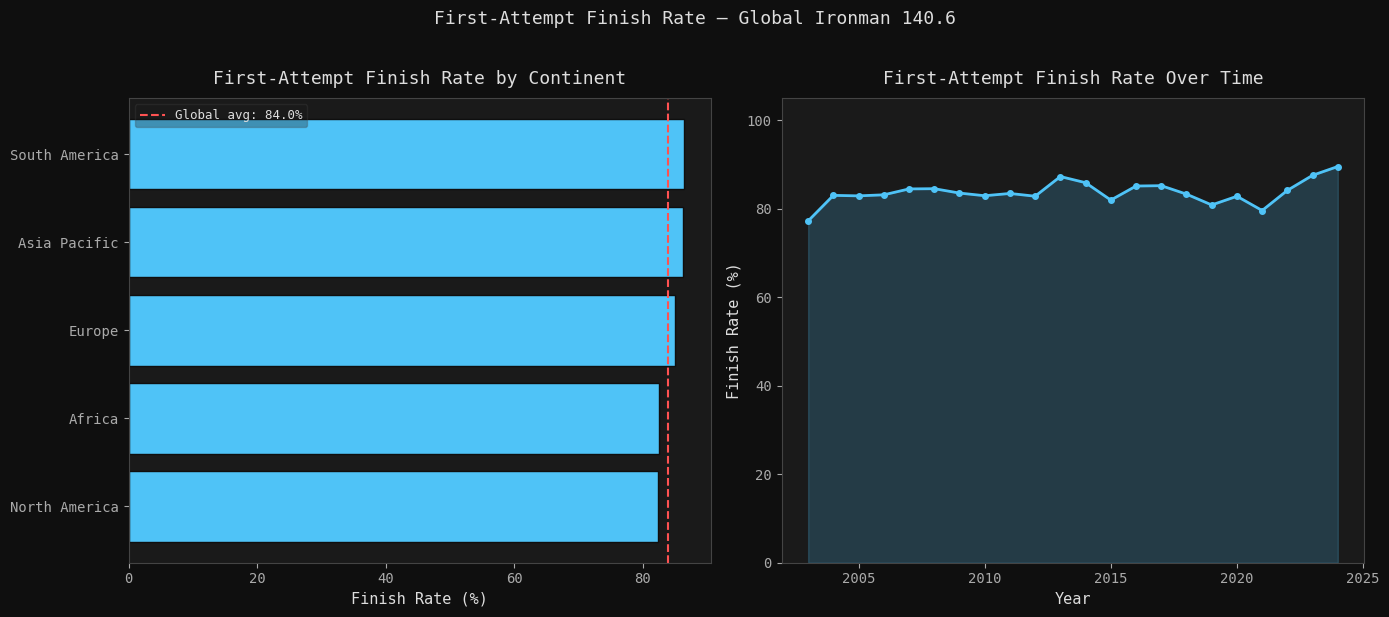

Saved: v13_eda_first_attempt.png


In [26]:
print('=== FIRST-ATTEMPT FINISH RATE ===')
first_attempts = df_all[df_all['Career_Sequence'] == 1].copy()
first_finishes = first_attempts[first_attempts['Finish_Status'].str.strip() == 'Finisher']
overall_rate   = len(first_finishes) / len(first_attempts)

print(f'Total first-ever entries : {len(first_attempts):,}')
print(f'Finished on first try    : {len(first_finishes):,}')
print(f'First-attempt finish rate: {overall_rate:.1%}')
print()
print('By continent:')
for cont in first_attempts['Race_Continent'].dropna().unique():
    fa = first_attempts[first_attempts['Race_Continent']==cont]
    ff = fa[fa['Finish_Status'].str.strip()=='Finisher']
    print(f'  {cont:<20}: {len(ff)/len(fa):.1%}  (n={len(fa):,})')
print()
print('By gender:')
for g in ['M','F']:
    fa = first_attempts[first_attempts['Gender']==g]
    ff = fa[fa['Finish_Status'].str.strip()=='Finisher']
    print(f'  {g}: {len(ff)/len(fa):.1%}  (n={len(fa):,})')

fig, axes = plt.subplots(1, 2, figsize=(14,6))

cont_rates = {}
for cont in first_attempts['Race_Continent'].dropna().unique():
    fa = first_attempts[first_attempts['Race_Continent']==cont]
    ff = fa[fa['Finish_Status'].str.strip()=='Finisher']
    cont_rates[cont] = len(ff)/len(fa) if len(fa)>0 else 0
cont_df = pd.DataFrame({'Continent':list(cont_rates.keys()),
                        'Rate':list(cont_rates.values())}).sort_values('Rate', ascending=True)
axes[0].barh(cont_df['Continent'], cont_df['Rate']*100, color='#4fc3f7', edgecolor='#0f0f0f')
axes[0].axvline(overall_rate*100, color='#ff5252', ls='--', lw=1.5,
                label=f'Global avg: {overall_rate:.1%}')
axes[0].set_title('First-Attempt Finish Rate by Continent', pad=10)
axes[0].set_xlabel('Finish Rate (%)')
axes[0].legend(fontsize=9, framealpha=0.3)

yearly_fa = first_attempts.groupby('Race_Year').apply(
    lambda x: (x['Finish_Status'].str.strip()=='Finisher').mean()).reset_index()
yearly_fa.columns = ['Race_Year','Finish_Rate']
axes[1].plot(yearly_fa['Race_Year'], yearly_fa['Finish_Rate']*100,
             color='#4fc3f7', linewidth=2, marker='o', markersize=4)
axes[1].fill_between(yearly_fa['Race_Year'], yearly_fa['Finish_Rate']*100, alpha=0.2, color='#4fc3f7')
axes[1].set_title('First-Attempt Finish Rate Over Time', pad=10)
axes[1].set_xlabel('Year'); axes[1].set_ylabel('Finish Rate (%)')
axes[1].set_ylim(0, 105)

plt.suptitle('First-Attempt Finish Rate — Global Ironman 140.6', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('v13_eda_first_attempt.png', dpi=150, bbox_inches='tight', facecolor='#0f0f0f')
plt.show()
print('Saved: v13_eda_first_attempt.png')

## Cell 25 · EDA — Expected Trials to Finish

=== EXPECTED TRIALS TO FINISH ===
Athletes who finished at least once: 464,533
Mean attempts    : 1.05
Median attempts  : 1
First try        : 95.9%
Within 3 tries   : 99.9%


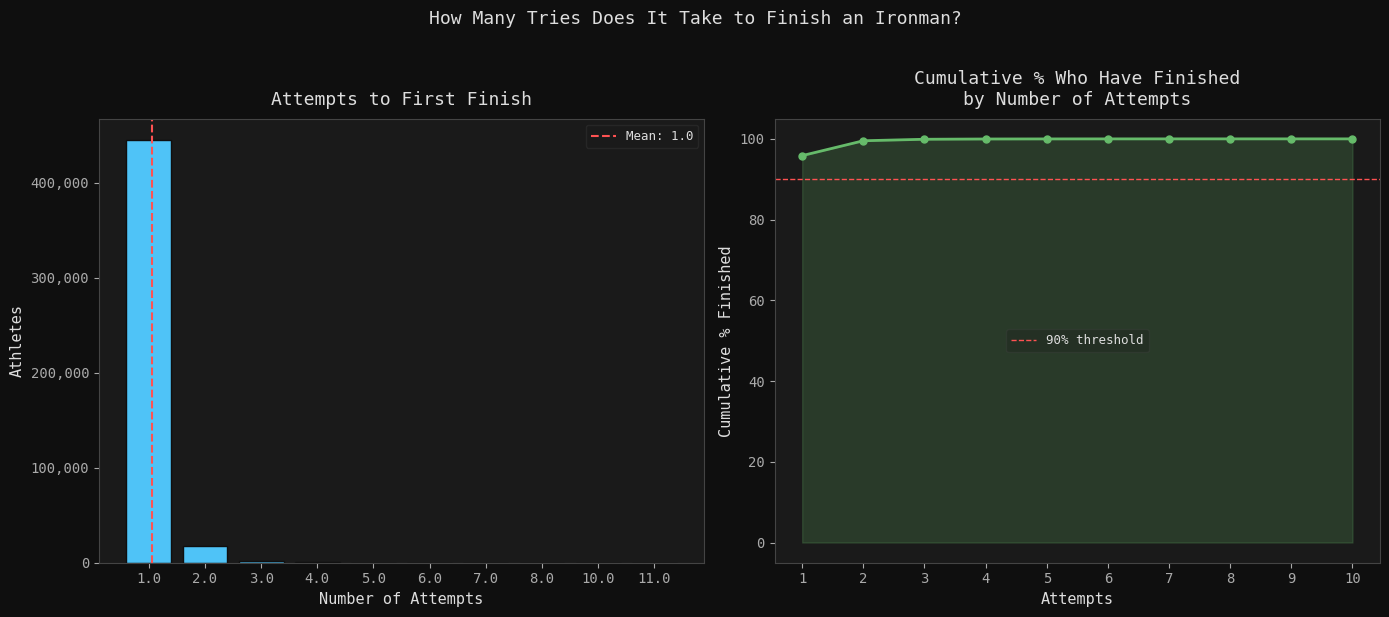

Saved: v13_eda_attempts.png


In [27]:
print('=== EXPECTED TRIALS TO FINISH ===')
first_finish_seq = (
    df_all[df_all['Finish_Status'].str.strip() == 'Finisher']
    .groupby(id_col)['Career_Sequence'].min().reset_index()
    .rename(columns={'Career_Sequence':'Attempts_To_First_Finish'})
)
print(f'Athletes who finished at least once: {len(first_finish_seq):,}')
mean_att  = first_finish_seq['Attempts_To_First_Finish'].mean()
med_att   = first_finish_seq['Attempts_To_First_Finish'].median()
pct_first = (first_finish_seq['Attempts_To_First_Finish']==1).mean()
pct_3     = (first_finish_seq['Attempts_To_First_Finish']<=3).mean()
print(f'Mean attempts    : {mean_att:.2f}')
print(f'Median attempts  : {med_att:.0f}')
print(f'First try        : {pct_first:.1%}')
print(f'Within 3 tries   : {pct_3:.1%}')

fig, axes = plt.subplots(1, 2, figsize=(14,6))
counts = first_finish_seq['Attempts_To_First_Finish'].value_counts().sort_index().head(10)
axes[0].bar(counts.index.astype(str), counts.values, color='#4fc3f7', edgecolor='#0f0f0f')
axes[0].set_title('Attempts to First Finish', pad=10)
axes[0].set_xlabel('Number of Attempts'); axes[0].set_ylabel('Athletes')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda y,_: f'{int(y):,}'))
axes[0].axvline(mean_att-1, color='#ff5252', ls='--', lw=1.5, label=f'Mean: {mean_att:.1f}')
axes[0].legend(fontsize=9, framealpha=0.3)

cum_pct = [(first_finish_seq['Attempts_To_First_Finish']<=i).mean()*100 for i in range(1,11)]
axes[1].plot(range(1,11), cum_pct, color='#66bb6a', linewidth=2, marker='o', markersize=5)
axes[1].fill_between(range(1,11), cum_pct, alpha=0.2, color='#66bb6a')
axes[1].set_title('Cumulative % Who Have Finished\nby Number of Attempts', pad=10)
axes[1].set_xlabel('Attempts'); axes[1].set_ylabel('Cumulative % Finished')
axes[1].set_xticks(range(1,11))
axes[1].axhline(90, color='#ff5252', ls='--', lw=1, label='90% threshold')
axes[1].legend(fontsize=9, framealpha=0.3)

plt.suptitle('How Many Tries Does It Take to Finish an Ironman?', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('v13_eda_attempts.png', dpi=150, bbox_inches='tight', facecolor='#0f0f0f')
plt.show()
print('Saved: v13_eda_attempts.png')

## Cell 26 · EDA — Expected Cost to Cross the Finish Line

Expected total race-day spend to first finish:
  Mean   : $   2,305
  Median : $   2,200
  75th % : $   2,200
  90th % : $   2,200

Note: Race-day costs only. Training costs ($3k-$20k+/yr) are additional.


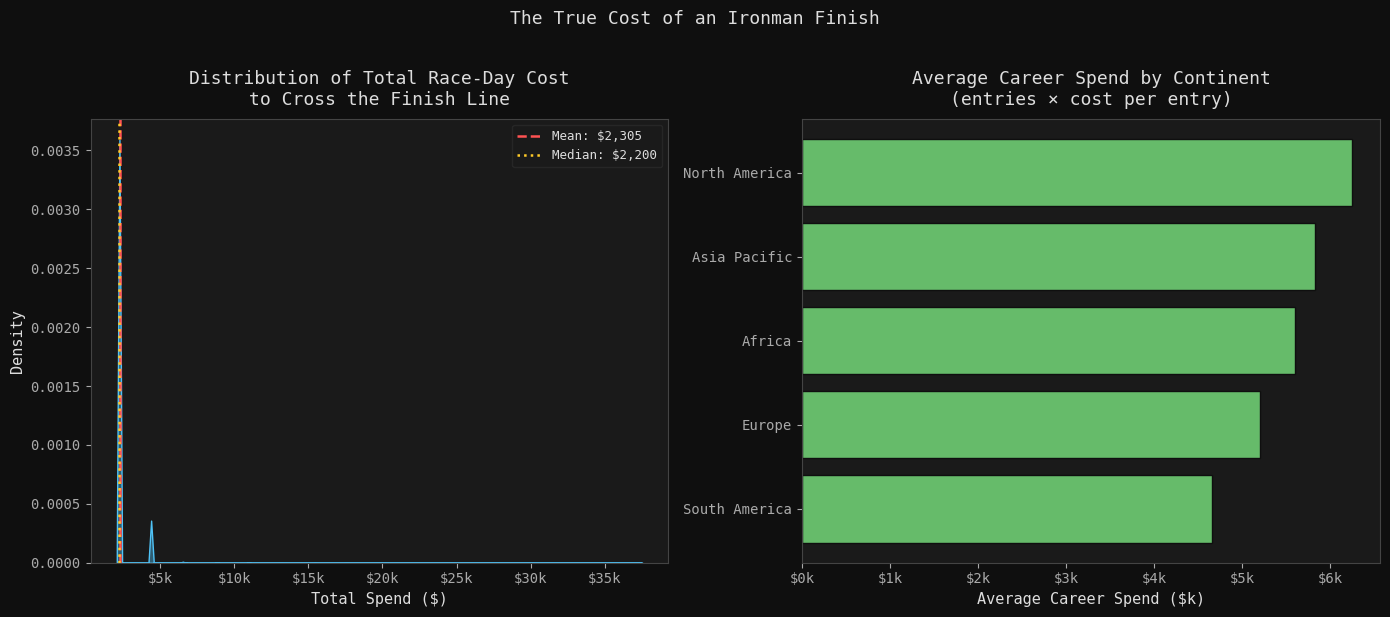

Saved: v13_eda_cost.png


In [28]:
COST_PER_ENTRY = 2_200  # entry + travel + lodging + nutrition + misc
cost_df = first_finish_seq.copy()
cost_df['Total_Cost'] = cost_df['Attempts_To_First_Finish'] * COST_PER_ENTRY

mean_cost   = cost_df['Total_Cost'].mean()
median_cost = cost_df['Total_Cost'].median()
p75_cost    = cost_df['Total_Cost'].quantile(0.75)
p90_cost    = cost_df['Total_Cost'].quantile(0.90)

print(f'Expected total race-day spend to first finish:')
print(f'  Mean   : ${mean_cost:>8,.0f}')
print(f'  Median : ${median_cost:>8,.0f}')
print(f'  75th % : ${p75_cost:>8,.0f}')
print(f'  90th % : ${p90_cost:>8,.0f}')
print()
print(f'Note: Race-day costs only. Training costs ($3k-$20k+/yr) are additional.')

fig, axes = plt.subplots(1, 2, figsize=(14,6))
sns.kdeplot(data=cost_df, x='Total_Cost', fill=True, color='#4fc3f7', alpha=0.4, ax=axes[0])
axes[0].axvline(mean_cost, color='#ff5252', ls='--', lw=1.8, label=f'Mean: ${mean_cost:,.0f}')
axes[0].axvline(median_cost, color='#ffca28', ls=':', lw=1.8, label=f'Median: ${median_cost:,.0f}')
axes[0].set_title('Distribution of Total Race-Day Cost\nto Cross the Finish Line', pad=10)
axes[0].set_xlabel('Total Spend ($)')
axes[0].set_ylabel('Density')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1000:.0f}k'))
axes[0].legend(framealpha=0.3, fontsize=9)

cont_seq = df_all.groupby('Race_Continent')['Career_Sequence'].mean()
axes[1].barh(cont_seq.sort_values().index,
             cont_seq.sort_values().values * COST_PER_ENTRY / 1000,
             color='#66bb6a', edgecolor='#0f0f0f')
axes[1].set_title('Average Career Spend by Continent\n(entries × cost per entry)', pad=10)
axes[1].set_xlabel('Average Career Spend ($k)')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:.0f}k'))

plt.suptitle('The True Cost of an Ironman Finish', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('v13_eda_cost.png', dpi=150, bbox_inches='tight', facecolor='#0f0f0f')
plt.show()
print('Saved: v13_eda_cost.png')

## Cell 27 · EDA — DNF Survival Curve

=== DNF SURVIVAL CURVE ===
 Attempts  Pct_Eventually_Finished      N
        1                 0.876527 529970
        2                 0.959994 192070
        3                 0.980498  98605
        4                 0.988650  58062
        5                 0.991847  37530
        6                 0.994182  25612
        7                 0.995549  18199
        8                 0.996791  13400
        9                 0.997230  10107
       10                 0.997300   7779


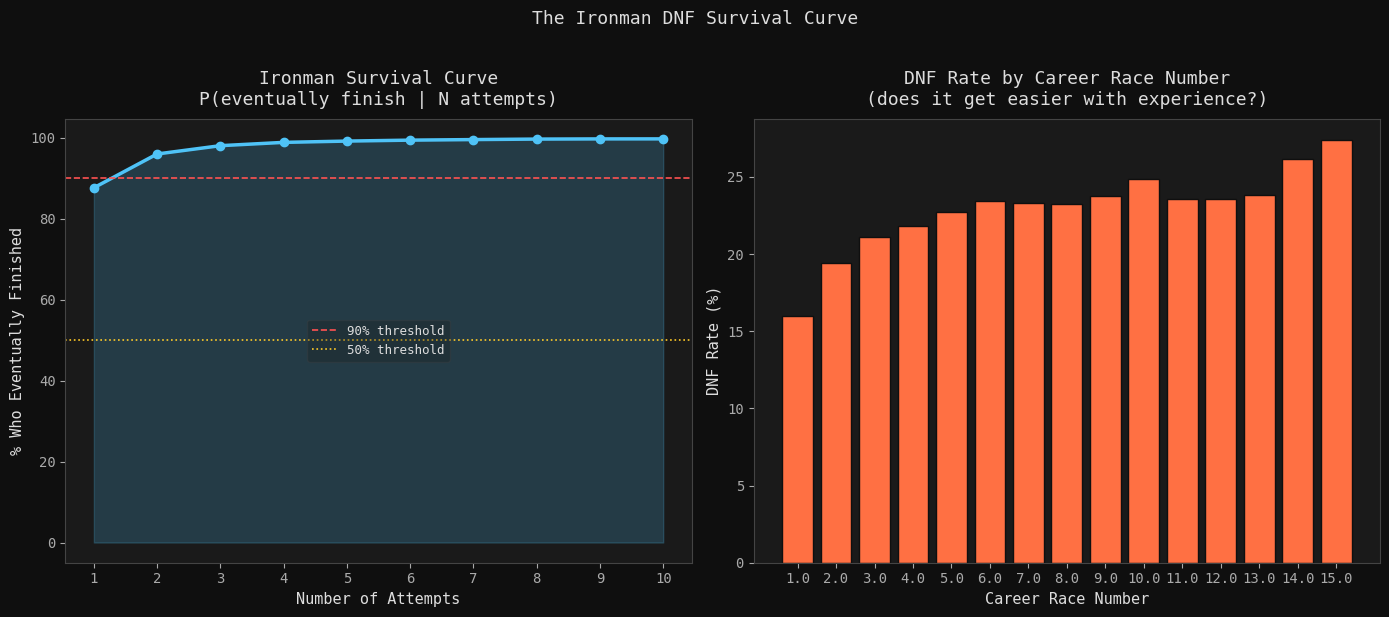

Saved: v13_eda_survival.png


In [29]:
print('=== DNF SURVIVAL CURVE ===')
athlete_summary = df_all.groupby(id_col).agg(
    Total_Entries = ('Race_ID','count'),
    Ever_Finished = ('Finish_Status', lambda x: (x.str.strip()=='Finisher').any()),
).reset_index()

max_att  = 10
survival = []
for n in range(1, max_att+1):
    at_n    = athlete_summary[athlete_summary['Total_Entries'] >= n]
    pct_fin = at_n['Ever_Finished'].mean() if len(at_n) > 0 else 0
    survival.append({'Attempts':n, 'Pct_Eventually_Finished':pct_fin, 'N':len(at_n)})
survival_df = pd.DataFrame(survival)
print(survival_df.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14,6))
axes[0].plot(survival_df['Attempts'], survival_df['Pct_Eventually_Finished']*100,
             color='#4fc3f7', linewidth=2.5, marker='o', markersize=6)
axes[0].fill_between(survival_df['Attempts'], survival_df['Pct_Eventually_Finished']*100,
                     alpha=0.2, color='#4fc3f7')
axes[0].axhline(90, color='#ff5252', ls='--', lw=1.2, label='90% threshold')
axes[0].axhline(50, color='#ffca28', ls=':', lw=1.2, label='50% threshold')
axes[0].set_title('Ironman Survival Curve\nP(eventually finish | N attempts)', pad=10)
axes[0].set_xlabel('Number of Attempts'); axes[0].set_ylabel('% Who Eventually Finished')
axes[0].set_xticks(range(1, max_att+1))
axes[0].legend(framealpha=0.3, fontsize=9)

dnf_by_seq = df_all.groupby('Career_Sequence').apply(
    lambda x: (x['Finish_Status'].str.strip()!='Finisher').mean()
).reset_index().head(15)
dnf_by_seq.columns = ['Career_Sequence','DNF_Rate']
axes[1].bar(dnf_by_seq['Career_Sequence'].astype(str), dnf_by_seq['DNF_Rate']*100,
            color='#ff7043', edgecolor='#0f0f0f')
axes[1].set_title('DNF Rate by Career Race Number\n(does it get easier with experience?)', pad=10)
axes[1].set_xlabel('Career Race Number'); axes[1].set_ylabel('DNF Rate (%)')

plt.suptitle('The Ironman DNF Survival Curve', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('v13_eda_survival.png', dpi=150, bbox_inches='tight', facecolor='#0f0f0f')
plt.show()
print('Saved: v13_eda_survival.png')

## Cell 28 · EDA — Age of Peak Performance (PROs Excluded)

PRO divisions are excluded from this plot. Their age was imputed as 33.0 — not real data —
and their finish times (~8h30m–9h30m) are incomparable to age-groupers, creating an
artificial performance spike at age 33.

=== AGE OF PEAK PERFORMANCE (AGE-GROUPERS ONLY) ===
Age-grouper records : 741,119
PRO records excluded: 11,439

Male peak age: 32 yrs  (mean: 12h11m)
Female peak age: 27 yrs  (mean: 13h6m)


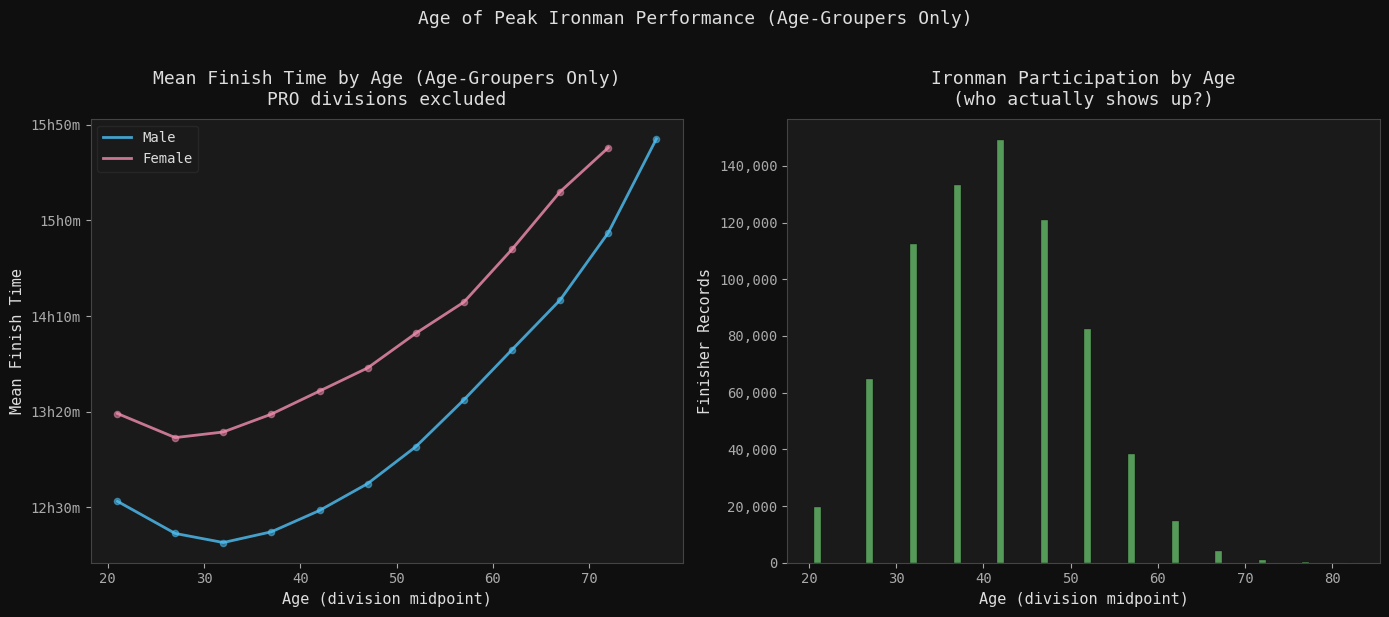

Saved: v13_eda_age_peak.png


In [30]:
print('=== AGE OF PEAK PERFORMANCE (AGE-GROUPERS ONLY) ===')

# Exclude PRO divisions — imputed age 33 is not real, performance is incomparable
is_pro = df['Division'].astype(str).str.upper().str.contains('PRO')
df_age = df[df['Age'].notna() & ~is_pro].copy()
print(f'Age-grouper records : {len(df_age):,}')
print(f'PRO records excluded: {is_pro.sum():,}')
print()

age_perf = df_age.groupby(['Age','Gender'])['Overall_Min'].agg(['mean','count']).reset_index()
age_perf = age_perf[age_perf['count'] >= 50]

for gender, label in [('M','Male'),('F','Female')]:
    subset = age_perf[age_perf['Gender']==gender]
    if len(subset) > 0:
        peak = subset.loc[subset['mean'].idxmin()]
        print(f'{label} peak age: {peak["Age"]:.0f} yrs  '
              f'(mean: {int(peak["mean"]//60)}h{int(peak["mean"]%60)}m)')

fig, axes = plt.subplots(1, 2, figsize=(14,6))
for gender, label, color in [('M','Male','#4fc3f7'),('F','Female','#f48fb1')]:
    subset = age_perf[age_perf['Gender']==gender].sort_values('Age')
    if len(subset) > 0:
        axes[0].plot(subset['Age'], subset['mean'], color=color, linewidth=2, label=label, alpha=0.8)
        axes[0].scatter(subset['Age'], subset['mean'], color=color, s=20, alpha=0.5)
axes[0].set_title('Mean Finish Time by Age (Age-Groupers Only)\nPRO divisions excluded', pad=10)
axes[0].set_xlabel('Age (division midpoint)'); axes[0].set_ylabel('Mean Finish Time')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda y,_: f"{int(y//60)}h{int(y%60)}m"))
axes[0].legend(framealpha=0.3)

age_part = df_age.groupby('Age').size().reset_index(name='Count')
axes[1].bar(age_part['Age'], age_part['Count'], color='#66bb6a', edgecolor='#0f0f0f', alpha=0.8, linewidth=0.3)
axes[1].set_title('Ironman Participation by Age\n(who actually shows up?)', pad=10)
axes[1].set_xlabel('Age (division midpoint)'); axes[1].set_ylabel('Finisher Records')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda y,_: f'{int(y):,}'))

plt.suptitle('Age of Peak Ironman Performance (Age-Groupers Only)', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('v13_eda_age_peak.png', dpi=150, bbox_inches='tight', facecolor='#0f0f0f')
plt.show()
print('Saved: v13_eda_age_peak.png')

## Cell 29 · EDA — Gender Gap Over Time (2002–2024)

=== GENDER GAP OVER TIME ===
2003 gap: +45.3 min (5.9%)
2024 gap: +45.1 min (6.1%)
Trend   : narrowing


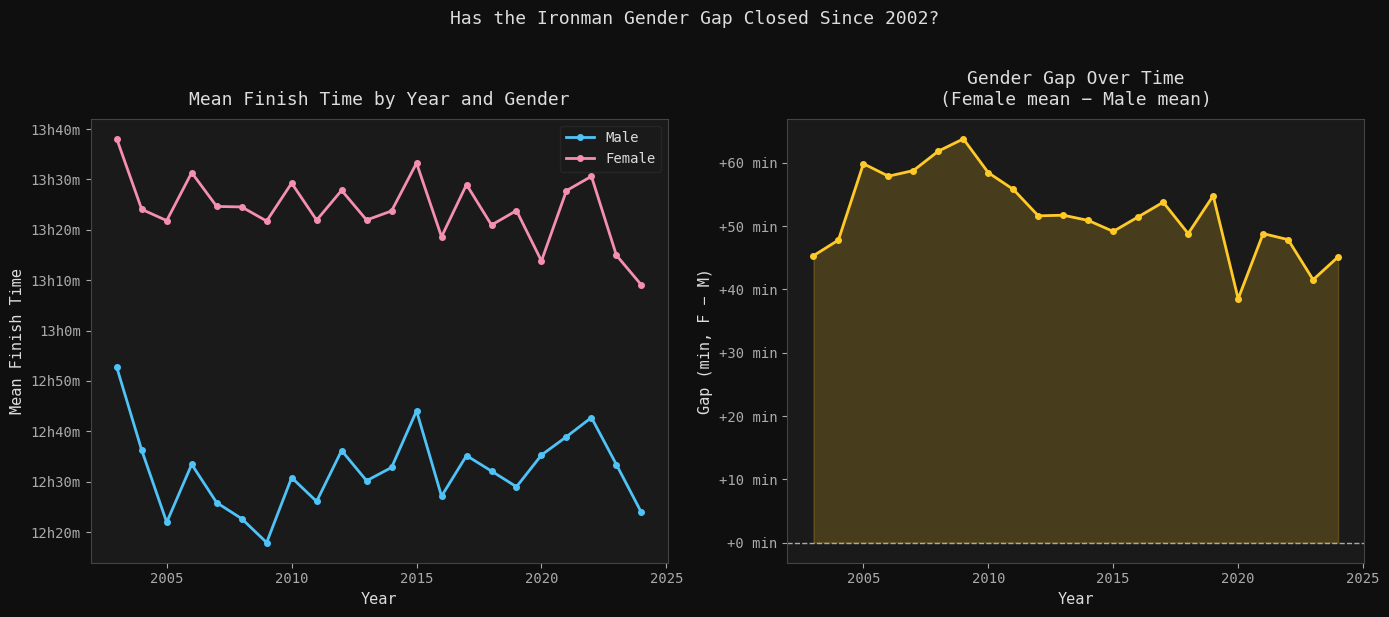

Saved: v13_eda_gender_gap.png


In [31]:
print('=== GENDER GAP OVER TIME ===')
gender_year = df.groupby(['Race_Year','Gender'])['Overall_Min'].agg(['mean','count']).reset_index()
gender_year.columns = ['Race_Year','Gender','Mean_Min','Count']
pivot = gender_year.pivot(index='Race_Year', columns='Gender', values='Mean_Min').dropna()
pivot['Gap_Min'] = pivot['F'] - pivot['M']
pivot['Gap_Pct'] = pivot['Gap_Min'] / pivot['M'] * 100

print(f'2003 gap: {pivot["Gap_Min"].iloc[0]:+.1f} min ({pivot["Gap_Pct"].iloc[0]:.1f}%)')
print(f'2024 gap: {pivot["Gap_Min"].iloc[-1]:+.1f} min ({pivot["Gap_Pct"].iloc[-1]:.1f}%)')
trend = "narrowing" if pivot["Gap_Min"].iloc[-1] < pivot["Gap_Min"].iloc[0] else "stable or widening"
print(f'Trend   : {trend}')

fig, axes = plt.subplots(1, 2, figsize=(14,6))
for gender, color, label in [('M','#4fc3f7','Male'),('F','#f48fb1','Female')]:
    g = gender_year[gender_year['Gender']==gender]
    axes[0].plot(g['Race_Year'], g['Mean_Min'], color=color, linewidth=2,
                 label=label, marker='o', markersize=4)
axes[0].set_title('Mean Finish Time by Year and Gender', pad=10)
axes[0].set_xlabel('Year'); axes[0].set_ylabel('Mean Finish Time')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda y,_: f"{int(y//60)}h{int(y%60)}m"))
axes[0].legend(framealpha=0.3)

axes[1].plot(pivot.index, pivot['Gap_Min'], color='#ffca28', linewidth=2, marker='o', markersize=4)
axes[1].fill_between(pivot.index, pivot['Gap_Min'], alpha=0.2, color='#ffca28')
axes[1].axhline(0, color='#aaaaaa', ls='--', lw=1)
axes[1].set_title('Gender Gap Over Time\n(Female mean − Male mean)', pad=10)
axes[1].set_xlabel('Year'); axes[1].set_ylabel('Gap (min, F − M)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda y,_: f'{y:+.0f} min'))

plt.suptitle('Has the Ironman Gender Gap Closed Since 2002?', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('v13_eda_gender_gap.png', dpi=150, bbox_inches='tight', facecolor='#0f0f0f')
plt.show()
print('Saved: v13_eda_gender_gap.png')

## Cell 30 · Final Visualizations

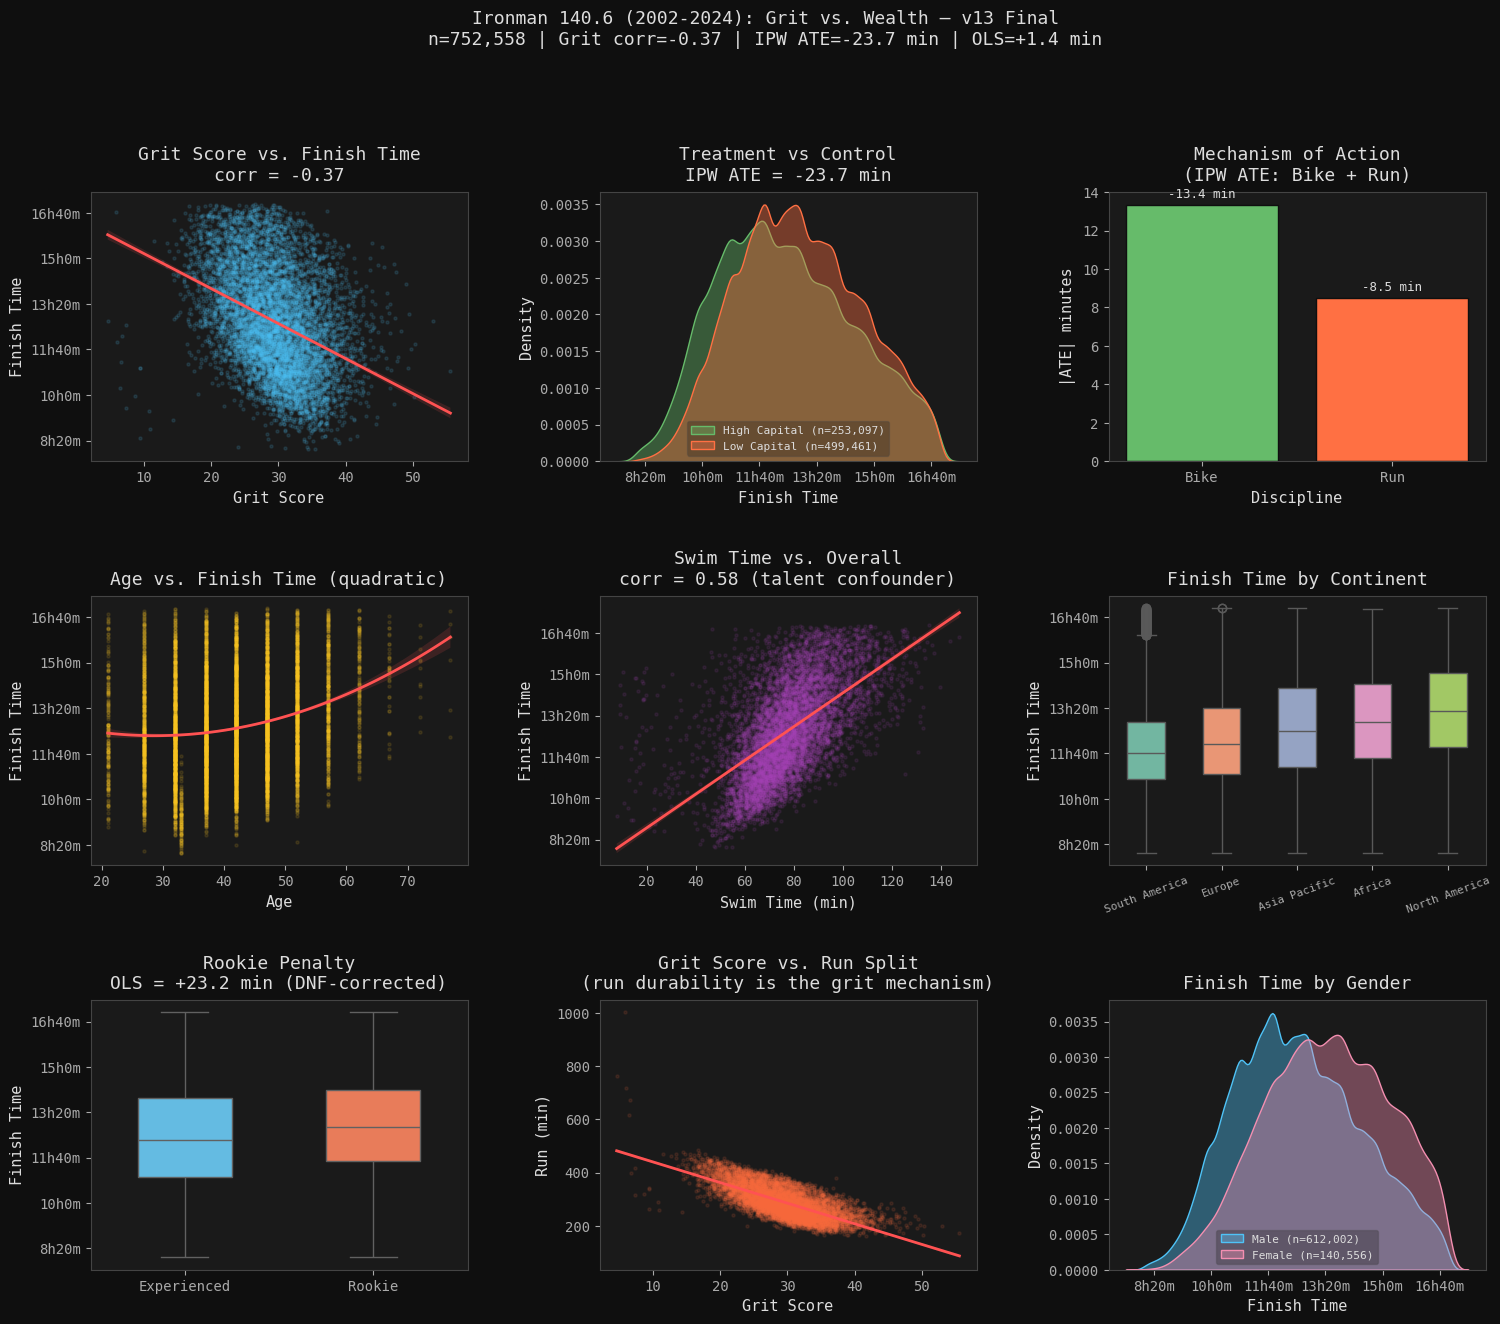

Saved: v13_plot3_final.png


In [32]:
fig = plt.figure(figsize=(18,14))
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.5, wspace=0.35)
axes = [fig.add_subplot(gs[r,c]) for r in range(3) for c in range(3)]
sample = df.sample(min(8000, len(df)), random_state=42)

ate_ipw_val = ate_ipw if not (isinstance(ate_ipw, float) and np.isnan(ate_ipw)) else None
ipw_lbl     = f'{ate_ipw_val:+.1f}' if ate_ipw_val is not None else 'N/A'
ols_lbl     = f'{ols_hcl_coef:+.1f}' if not np.isnan(ols_hcl_coef) else 'N/A'

# P1: Grit vs Overall
sns.regplot(data=sample, x='Grit_Score', y='Overall_Min',
    scatter_kws={'alpha':0.12,'color':'#4fc3f7','s':5},
    line_kws={'color':'#ff5252','linewidth':2}, ax=axes[0])
axes[0].set_title(f'Grit Score vs. Finish Time\ncorr = {grit_corr:.2f}', pad=8)
axes[0].set_xlabel('Grit Score'); axes[0].set_ylabel('Finish Time')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda y,_: f"{int(y//60)}h{int(y%60)}m"))

# P2: Treatment vs Control KDE
for val, color, label in [(1,'#66bb6a','High Capital'),(0,'#ff7043','Low Capital')]:
    subset = df[df['High_Capital_Lifestyle']==val]
    sns.kdeplot(data=subset, x='Overall_Min', fill=True, color=color, alpha=0.4,
                label=f'{label} (n={len(subset):,})', ax=axes[1])
axes[1].set_title(f'Treatment vs Control\nIPW ATE = {ipw_lbl} min', pad=8)
axes[1].set_xlabel('Finish Time'); axes[1].set_ylabel('Density')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"{int(x//60)}h{int(x%60)}m"))
axes[1].legend(framealpha=0.3, fontsize=8)

# P3: Mechanism of action
if valid_ates and total_abs > 0:
    labels_m = [k.replace('_Min','') for k in valid_ates.keys()]
    values_m = list(valid_ates.values())
    colors_m = ['#66bb6a','#ff7043']
    bars_m   = axes[2].bar(labels_m, [abs(v) for v in values_m],
                            color=colors_m[:len(labels_m)], edgecolor='#0f0f0f')
    for bar, val in zip(bars_m, values_m):
        axes[2].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.2,
                     f'{val:+.1f} min', ha='center', va='bottom', fontsize=9)
    axes[2].set_title('Mechanism of Action\n(IPW ATE: Bike + Run)', pad=8)
    axes[2].set_xlabel('Discipline'); axes[2].set_ylabel('|ATE| minutes')

# P4: Age quadratic
sns.regplot(data=sample, x='Age', y='Overall_Min', order=2,
    scatter_kws={'alpha':0.1,'color':'#ffca28','s':5},
    line_kws={'color':'#ff5252','linewidth':2}, ax=axes[3])
axes[3].set_title('Age vs. Finish Time (quadratic)', pad=8)
axes[3].set_xlabel('Age'); axes[3].set_ylabel('Finish Time')
axes[3].yaxis.set_major_formatter(mticker.FuncFormatter(lambda y,_: f"{int(y//60)}h{int(y%60)}m"))

# P5: Swim baseline
sns.regplot(data=sample, x='Swim_Min', y='Overall_Min',
    scatter_kws={'alpha':0.1,'color':'#ab47bc','s':5},
    line_kws={'color':'#ff5252','linewidth':2}, ax=axes[4])
axes[4].set_title(f'Swim Time vs. Overall\ncorr = {swim_corr:.2f} (talent confounder)', pad=8)
axes[4].set_xlabel('Swim Time (min)'); axes[4].set_ylabel('Finish Time')
axes[4].yaxis.set_major_formatter(mticker.FuncFormatter(lambda y,_: f"{int(y//60)}h{int(y%60)}m"))

# P6: Continent
cont_order = df.groupby('Race_Continent')['Overall_Min'].median().sort_values().index.tolist()
sns.boxplot(data=df, x='Race_Continent', y='Overall_Min', order=cont_order,
    palette='Set2', width=0.5, ax=axes[5])
axes[5].set_title('Finish Time by Continent', pad=8)
axes[5].set_xlabel(''); axes[5].set_ylabel('Finish Time')
axes[5].tick_params(axis='x', rotation=20, labelsize=8)
axes[5].yaxis.set_major_formatter(mticker.FuncFormatter(lambda y,_: f"{int(y//60)}h{int(y%60)}m"))

# P7: Rookie penalty
sns.boxplot(data=df, x='Rookie_Status', y='Overall_Min',
    palette=['#4fc3f7','#ff7043'], width=0.5, ax=axes[6])
axes[6].set_xticklabels(['Experienced','Rookie'])
axes[6].set_title(f'Rookie Penalty\nOLS = {ols_rookie_coef:+.1f} min (DNF-corrected)', pad=8)
axes[6].set_xlabel(''); axes[6].set_ylabel('Finish Time')
axes[6].yaxis.set_major_formatter(mticker.FuncFormatter(lambda y,_: f"{int(y//60)}h{int(y%60)}m"))

# P8: Grit vs Run
sns.regplot(data=sample, x='Grit_Score', y='Run_Min',
    scatter_kws={'alpha':0.1,'color':'#ff7043','s':5},
    line_kws={'color':'#ff5252','linewidth':2}, ax=axes[7])
axes[7].set_title('Grit Score vs. Run Split\n(run durability is the grit mechanism)', pad=8)
axes[7].set_xlabel('Grit Score'); axes[7].set_ylabel('Run (min)')

# P9: Gender
for gender, color, label in [('M','#4fc3f7','Male'),('F','#f48fb1','Female')]:
    subset = df[df['Gender']==gender]
    if len(subset)>0:
        sns.kdeplot(data=subset, x='Overall_Min', fill=True, color=color, alpha=0.4,
                    label=f'{label} (n={len(subset):,})', ax=axes[8])
axes[8].set_title('Finish Time by Gender', pad=8)
axes[8].set_xlabel('Finish Time'); axes[8].set_ylabel('Density')
axes[8].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"{int(x//60)}h{int(x%60)}m"))
axes[8].legend(framealpha=0.3, fontsize=8)

fig.suptitle(
    f'Ironman 140.6 (2002-2024): Grit vs. Wealth — v13 Final\n'
    f'n={len(df):,} | Grit corr={grit_corr:.2f} | IPW ATE={ipw_lbl} min | OLS={ols_lbl} min',
    fontsize=13, y=1.01)
plt.savefig('v13_plot3_final.png', dpi=150, bbox_inches='tight', facecolor='#0f0f0f')
plt.show()
print('Saved: v13_plot3_final.png')

## Cell 31 · Study Summary

In [33]:
ate_ipw_val = ate_ipw if not (isinstance(ate_ipw, float) and np.isnan(ate_ipw)) else None
fc_corr     = df[['High_Capital_Lifestyle','Overall_Min']].corr().iloc[0,1]
rookie_corr = df[['Rookie_Status','Overall_Min']].corr().iloc[0,1]
age_corr    = df[['Age','Overall_Min']].corr().iloc[0,1]
d_ols       = (ate_ipw_val < 0) == (ols_hcl_coef < 0) if ate_ipw_val is not None else None

print('='*70)
print('IRONMAN GRIT VS. WEALTH — v13 FINAL GLOBAL')
print('='*70)
print(f'  Dataset        : Ironman 140.6 Results 2002-2024 (miguswong/Kaggle)')
print(f'  Scope          : GLOBAL (all continents)')
print(f'  Total Records  : {len(df):,} finisher records')
print(f'  Unique Athletes: {df[id_col].nunique():,}')
print(f'  Race Years     : {df["Race_Year"].min():.0f} - {df["Race_Year"].max():.0f}')
print()
print('  -- Continent Breakdown ----------------------------------------')
for cont, cnt in df['Race_Continent'].value_counts().items():
    print(f'  {cont:<20}: {cnt:>8,} ({cnt/len(df):.1%})')
print()
print('  -- Treatment Variable -----------------------------------------')
print(f'  High_Capital_Lifestyle : {df["High_Capital_Lifestyle"].mean():.1%}')
print(f'  Definition             : 2nd+ entry this year OR raced prior year')
print()
print('  -- Feature Correlations with Overall_Min ----------------------')
print(f'  Grit_Score             : {grit_corr:+.3f}  <- primary driver')
print(f'  Swim_Min               : {swim_corr:+.3f}')
print(f'  High_Capital_Lifestyle : {fc_corr:+.3f}')
print(f'  Age                    : {age_corr:+.3f}')
print(f'  Rookie_Status          : {rookie_corr:+.3f}')
print()
print('  -- Three-Model Results ----------------------------------------')
ipw_s = f'{ate_ipw_val:+.3f} min' if ate_ipw_val is not None else 'unavailable'
psm_s = f'{ate_psm:+.3f} min' if ate_psm is not None else 'None'
print(f'  IPW ATE (primary, full data) : {ipw_s}')
print(f'  PSM ATE (robustness, 50k)    : {psm_s}')
print(f'  OLS coef (venue FE, 50k)     : {ols_hcl_coef:+.3f} min (p={ols_result.pvalues.get("High_Capital_Lifestyle", 1):.4f})')
print(f'  OLS Grit coef                : {ols_grit_coef:+.3f} min/point')
print(f'  OLS R-squared                : {ols_result.rsquared:.4f}')
print(f'  IPW/OLS consistent           : {"YES" if d_ols else "NO — see README"}')
print()
print('  -- Mechanism (Split ATE: Bike + Run) --------------------------')
if valid_ates and total_abs > 0:
    for seg, val in valid_ates.items():
        pct = (abs(val)/total_abs)*100
        print(f'  {seg.replace("_Min",""):<5}: {val:+.2f} min  ({pct:.0f}%)')
    print(f'  {mechanism}')
print()
print(f'  VERDICT: {verdict}')
print('='*70)

IRONMAN GRIT VS. WEALTH — v13 FINAL GLOBAL
  Dataset        : Ironman 140.6 Results 2002-2024 (miguswong/Kaggle)
  Scope          : GLOBAL (all continents)
  Total Records  : 752,558 finisher records
  Unique Athletes: 451,508
  Race Years     : 2003 - 2024

  -- Continent Breakdown ----------------------------------------
  North America       :  331,243 (44.0%)
  Europe              :  293,702 (39.0%)
  Asia Pacific        :   90,306 (12.0%)
  South America       :   23,149 (3.1%)
  Africa              :   14,158 (1.9%)

  -- Treatment Variable -----------------------------------------
  High_Capital_Lifestyle : 33.6%
  Definition             : 2nd+ entry this year OR raced prior year

  -- Feature Correlations with Overall_Min ----------------------
  Grit_Score             : -0.369  <- primary driver
  Swim_Min               : +0.580
  High_Capital_Lifestyle : -0.104
  Age                    : +0.209
  Rookie_Status          : +0.111

  -- Three-Model Results ----------------------

## Cell 32 · Grit-to-Capital Exchange Rate

In [34]:
ate_ipw_val   = ate_ipw if not (isinstance(ate_ipw, float) and np.isnan(ate_ipw)) else None
grit_coef_abs = abs(ols_grit_coef) if not np.isnan(ols_grit_coef) else None
wealth_abs    = abs(ate_ipw_val) if ate_ipw_val is not None else None

print('='*60)
print('THE GRIT-TO-CAPITAL EXCHANGE RATE')
print('='*60)

if grit_coef_abs and wealth_abs and grit_coef_abs > 0:
    exchange_rate = wealth_abs / grit_coef_abs
    grit_std      = df['Grit_Score'].std()
    std_shifts    = exchange_rate / grit_std
    print(f'  Wealth ATE (IPW)   : {ate_ipw_val:+.2f} minutes')
    print(f'  Grit OLS coef      : {ols_grit_coef:+.4f} min per grit point')
    print(f'  Exchange Rate      : {exchange_rate:.1f} grit points = 1 capital event')
    print(f'  In std dev terms   : {std_shifts:.2f} SDs of Grit')
    print()
    print(f'  Capital buys {wealth_abs:.1f} minutes.')
    print(f'  Earning that naturally requires {exchange_rate:.1f} grit points.')
    print()
    if exchange_rate > 30:   print('  VERDICT: Capital is buying a massive shortcut.')
    elif exchange_rate > 10: print('  VERDICT: Meaningful but not insurmountable advantage.')
    else:                    print('  VERDICT: A modest Grit improvement matches the capital edge.')
else:
    exchange_rate = None
    print('  Exchange rate unavailable.')
print('='*60)

THE GRIT-TO-CAPITAL EXCHANGE RATE
  Wealth ATE (IPW)   : -23.73 minutes
  Grit OLS coef      : -8.5780 min per grit point
  Exchange Rate      : 2.8 grit points = 1 capital event
  In std dev terms   : 0.51 SDs of Grit

  Capital buys 23.7 minutes.
  Earning that naturally requires 2.8 grit points.

  VERDICT: A modest Grit improvement matches the capital edge.


## Cell 33 · Cost Per Minute of Bought Speed

In [35]:
COST_CONSERVATIVE = 5_700
COST_PREMIUM      = 10_000
ate_ipw_val = ate_ipw if not (isinstance(ate_ipw, float) and np.isnan(ate_ipw)) else None

print('='*60)
print('COST PER MINUTE OF BOUGHT SPEED')
print('='*60)
if ate_ipw_val and abs(ate_ipw_val) > 0:
    m = abs(ate_ipw_val)
    lo = COST_CONSERVATIVE / m
    hi = COST_PREMIUM / m
    headline = (lo + hi) / 2
    print(f'  Minutes saved (IPW ATE)    : {m:.1f} minutes')
    print(f'  Conservative ($5,700 spend): ${lo:,.0f}/min')
    print(f'  Premium ($10,000 spend)    : ${hi:,.0f}/min')
    print(f'  Headline                   : ~${headline:,.0f}/min  (~${headline*60:,.0f}/hr of speed)')
else:
    headline = None
    print('  Unavailable.')
print('='*60)

COST PER MINUTE OF BOUGHT SPEED
  Minutes saved (IPW ATE)    : 23.7 minutes
  Conservative ($5,700 spend): $240/min
  Premium ($10,000 spend)    : $421/min
  Headline                   : ~$331/min  (~$19,845/hr of speed)


## Cell 34 · Split Decoder — Comment Bait CTA

In [36]:
def classify_athlete(swim_hhmm, bike_hhmm, run_hhmm):
    def parse(t):
        try:
            parts = str(t).strip().split(':')
            if len(parts)==2: return int(parts[0])*60+int(parts[1])
            if len(parts)==3: return int(parts[0])*60+int(parts[1])+int(parts[2])/60
        except: pass
        return None
    swim=parse(swim_hhmm); bike=parse(bike_hhmm); run=parse(run_hhmm)
    if not all([swim,bike,run]): return None
    pace_ratio = (run/26.2)/(bike/112.0)
    raw_grit   = 1.0/pace_ratio if pace_ratio>0 else 0
    score      = max(0, min(100, (raw_grit-df['Grit_Raw'].min()) /
                             (df['Grit_Raw'].max()-df['Grit_Raw'].min())*100))
    overall    = swim+bike+run+15
    h,m        = int(overall//60), int(overall%60)
    if score>=65:   cls,interp = 'GRIT-DOMINANT','Your run held. Training consistency signature.'
    elif score>=40: cls,interp = 'BALANCED','Mix of fitness and discipline.'
    else:           cls,interp = 'CAPITAL-ASSISTED','Run decayed vs bike. Equipment or coaching advantage.'
    return score, cls, interp, h, m

examples = [
    ('1:05','5:12','3:58','Elite Age-Grouper'),
    ('1:15','4:45','4:30','Mid-Pack'),
    ('1:20','5:30','5:45','First-Timer'),
    ('1:08','4:30','5:20','Strong Biker, Run Fell Apart'),
    ('1:18','5:50','4:15','Negative Split Runner'),
]
print('='*65)
print('SPLIT DECODER — GRIT vs. CAPITAL CLASSIFIER')
print('Drop your splits in the comments!')
print('='*65)
print()
for swim,bike,run,label in examples:
    r = classify_athlete(swim,bike,run)
    if r:
        score,cls,interp,h,m = r
        print(f'  {label}')
        print(f'  Splits  : Swim {swim} | Bike {bike} | Run {run}')
        print(f'  Finish  : ~{h}h {m}m  |  Grit: {score:.0f}/100  |  {cls}')
        print(f'  Verdict : {interp}')
        print()
print('VIDEO CTA: "Drop your 140.6 splits in the comments.')
print('I will tell you if you finished on Grit or Capital."')

SPLIT DECODER — GRIT vs. CAPITAL CLASSIFIER
Drop your splits in the comments!

  Elite Age-Grouper
  Splits  : Swim 1:05 | Bike 5:12 | Run 3:58
  Finish  : ~10h 30m  |  Grit: 35/100  |  CAPITAL-ASSISTED
  Verdict : Run decayed vs bike. Equipment or coaching advantage.

  Mid-Pack
  Splits  : Swim 1:15 | Bike 4:45 | Run 4:30
  Finish  : ~10h 45m  |  Grit: 26/100  |  CAPITAL-ASSISTED
  Verdict : Run decayed vs bike. Equipment or coaching advantage.

  First-Timer
  Splits  : Swim 1:20 | Bike 5:30 | Run 5:45
  Finish  : ~12h 50m  |  Grit: 22/100  |  CAPITAL-ASSISTED
  Verdict : Run decayed vs bike. Equipment or coaching advantage.

  Strong Biker, Run Fell Apart
  Splits  : Swim 1:08 | Bike 4:30 | Run 5:20
  Finish  : ~11h 13m  |  Grit: 18/100  |  CAPITAL-ASSISTED
  Verdict : Run decayed vs bike. Equipment or coaching advantage.

  Negative Split Runner
  Splits  : Swim 1:18 | Bike 5:50 | Run 4:15
  Finish  : ~11h 38m  |  Grit: 38/100  |  CAPITAL-ASSISTED
  Verdict : Run decayed vs bike. 

## Cell 35 · Final TL;DR — ASCII Summary

In [38]:
ate_ipw_val = ate_ipw if not (isinstance(ate_ipw, float) and np.isnan(ate_ipw)) else None
ipw_lbl  = f'{ate_ipw_val:+.1f} min' if ate_ipw_val is not None else 'N/A'
ols_lbl  = f'{ols_hcl_coef:+.1f} min' if not np.isnan(ols_hcl_coef) else 'N/A'

if ate_ipw_val and not np.isnan(ols_grit_coef) and abs(ols_grit_coef)>0:
    ex_rate = f'{abs(ate_ipw_val)/abs(ols_grit_coef):.0f} grit points'
else:
    ex_rate = 'N/A'

try:    mech_str = dominant_label if dominant else 'Bike'
except: mech_str = 'Bike'

abs_ate       = abs(ate_ipw_val) if ate_ipw_val else 0.0
line_records  = f"{len(df):,} finisher records  |  Global  |  2002-2024"
line_athletes = f"{df[id_col].nunique():,} unique athletes  |  {df['Race_Year'].min():.0f} - {df['Race_Year'].max():.0f}"
line_ipw      = f"IPW Causal ATE  : {ipw_lbl}  (primary, full data)"
line_ols      = f"OLS Coefficient : {ols_lbl}  (venue-controlled, 50k sample)"
line_mech     = f"Primary mechanism: {mech_str}"
line_cap      = f"Capital buys {abs_ate:.1f} minutes."
line_grit     = f"Matching that with Grit alone requires {ex_rate}"
line_footer   = "Built by 雲 |  @_yuncl  |  @yunvo.fit"

print(f"""╔══════════════════════════════════════════════════════════════════════╗
║  {'IRONMAN 140.6 (2002–2024): GRIT vs. WEALTH':<68}║
║  {'A Causal Inference Study   |   github.com/burgeoned':<68}║
╠══════════════════════════════════════════════════════════════════════╣
║  {'':<68}║
║  {'THE QUESTION':<68}║
║  {'Among athletes who can afford to enter an Ironman,':<68}║
║  {'does spending MORE money (racing 2x in 24 months) buy speed?':<68}║
║  {'':<68}║
║  {'THE DATA (GLOBAL)':<68}║
║  {line_records:<68}║
║  {line_athletes:<68}║
║  {'':<68}║
║  {'WHAT WE CONTROLLED FOR':<68}║
║  {'• Biology    : Age, Age², Gender':<68}║
║  {'• Talent     : Swim time (baseline physical ability)':<68}║
║  {'• Grit       : Run/Bike pace ratio (late-race durability)':<68}║
║  {'• Experience : Rookie status, historical DNF count':<68}║
║  {'• Freshness  : Must have raced within the last 2 years':<68}║
║  {'• Conditions : Venue + Year fixed effects (OLS only)':<68}║
║  {'':<68}║
║  {'THE ANSWER':<68}║
║  {line_ipw:<68}║
║  {line_ols:<68}║
║  {line_mech:<68}║
║  {'':<68}║
║  {'THE EXCHANGE RATE':<68}║
║  {line_cap:<68}║
║  {line_grit:<68}║
║  {'Money lets you skip the suffering.':<68}║
║  {'':<68}║
║  {'THE CAVEAT':<68}║
║  {'ATE is a CONSERVATIVE LOWER BOUND.':<68}║
║  {'All athletes already cleared a ~$3k entry barrier.':<68}║
║  {'True wealth effect is at least this large, likely larger.':<68}║
║  {'':<68}║
║  {'METHODOLOGY':<68}║
║  {'IPW (DoWhy, full data) + OLS (venue FE, 50k) + PSM (50k)':<68}║
║  {'Dataset: miguswong/ironman-140-6-results-dataset-2002-2024':<68}║
║  {'Python: pandas · numpy · dowhy · statsmodels · seaborn':<68}║
║  {'':<68}║
║  {line_footer:<67}║
╚══════════════════════════════════════════════════════════════════════╝""")

╔══════════════════════════════════════════════════════════════════════╗
║  IRONMAN 140.6 (2002–2024): GRIT vs. WEALTH                          ║
║  A Causal Inference Study   |   github.com/burgeoned                 ║
╠══════════════════════════════════════════════════════════════════════╣
║                                                                      ║
║  THE QUESTION                                                        ║
║  Among athletes who can afford to enter an Ironman,                  ║
║  does spending MORE money (racing 2x in 24 months) buy speed?        ║
║                                                                      ║
║  THE DATA (GLOBAL)                                                   ║
║  752,558 finisher records  |  Global  |  2002-2024                   ║
║  451,508 unique athletes  |  2003 - 2024                             ║
║                                                                      ║
║  WHAT WE CONTROLLED FOR                          